# Streaming Decoder Visualizations

This notebook visualizes results saved by `save_split_results()` / `load_split_results()`.

Each split is stored in two files:
- `{split}_metadata.parquet` — scalar + list columns (WER, glosses, predictions, segments)
- `{split}_arrays.npz` — per-frame logit arrays (logits, probs, labels, states)

**Cells are organized by visualization type:**
1. Imports & Constants
2. I/O Helpers
3. Color Palette Helpers
4. Plot 1 — Sequence Timeline
5. Plot 2 — Post-bag Confidence Heatmap
6. Plot 3 — WER Distribution
7. Plot 4 — Split Overview Grid
8. Plot 5 — Sign-level Confusion Matrix
9. Convenience — Batch Export All Sequences
10. Run Everything

---
## 1. Imports & Constants

In [28]:
from __future__ import annotations

import json
import os
from typing import Sequence

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# Constants — must match the values used in the decoder
# ---------------------------------------------------------------------------

# Directory where the .parquet and .npz result files live
RESULTS_DIR = "./"

# Frames per second captured by the Leap Motion sensor
LEAP_FPS = 30

# Number of consecutive frames whose votes are majority-pooled before
# committing a label (the "bag" in bag-of-frames decoding)
BAG_SIZE = 5

# Minimum post-bag top-1 probability required to accept a sign prediction
CONFIDENCE_THRESHOLD = 0.35

# Minimum gap between the top-1 sign probability and the background probability;
# if the gap is smaller the frame is treated as background
SIGN_BG_MARGIN = 0.10

# Label string used for the background / no-sign class
BACKGROUND_LABEL = "background"  # change if your project uses a different name

---
## 2. I/O Helpers
Functions to load saved split results from disk and extract per-sequence arrays.

In [29]:
def load_split_results(
    split_name: str,
    results_dir: str = RESULTS_DIR,
) -> tuple[pd.DataFrame, dict]:
    """
    Load metadata DataFrame and per-frame arrays for one split.

    Reads two files written by save_split_results():
        {slug}_metadata.parquet  — WER scalars, GT glosses, predictions,
                                   emit_regions and gt_segments (as JSON strings)
        {slug}_arrays.npz        — per-frame logit/prob/label/state arrays

    Parameters
    ----------
    split_name  : e.g. "test", "dev_val", "test_(user1)" — must match
                  the slug used when saving
    results_dir : directory containing the parquet / npz files

    Returns
    -------
    df     : DataFrame with all scalars + list columns
    arrays : dict keyed by "{row_idx}__{rec_id}__{field}"
    """
    slug = (
        split_name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
    )
    parquet_path = os.path.join(results_dir, f"{slug}_metadata.parquet")
    npz_path     = os.path.join(results_dir, f"{slug}_arrays.npz")

    df = pd.read_parquet(parquet_path)

    def _deserialize_regions(x) -> list[tuple]:
        if not isinstance(x, str):
            return []
        out = []
        for r in json.loads(x):
            if isinstance(r, dict):
                # gt_segments saved as dicts — extract values by key
                out.append((int(r["start_frame"]), int(r["end_frame"]), str(r["label"])))
            elif isinstance(r, (list, tuple)) and len(r) >= 3:
                # emit_regions saved as lists — cast directly
                out.append((int(r[0]), int(r[1]), str(r[2])))
        return out

    for col in ["emit_regions", "gt_segments"]:
        if col in df.columns:
            df[col] = df[col].apply(_deserialize_regions)

    npz    = np.load(npz_path, allow_pickle=True)
    arrays = {k: npz[k] for k in npz.files}

    return df, arrays


def get_sequence_arrays(row: pd.Series, arrays: dict) -> dict:
    """
    Extract all per-frame arrays for a single DataFrame row.

    Constructs the key prefix from the row index and recording_id,
    then pulls every stored field from the shared arrays dict.

    Returns
    -------
    dict with keys:
        pre_bag_logits  (T, C) float32  — raw model logits before bag pooling
        post_bag_probs  (T, C) float32  — softmax probs after bag; first
                                          (BAG_SIZE-1) rows are NaN
        frame_indices   (T,)   int32    — original frame numbers
        raw_labels      (T,)   object   — per-frame pre-bag top-1 label string
        voted_labels    (T,)   object   — post-bag majority-vote label string
        raw_conf        (T,)   float32  — pre-bag top-1 confidence
        bg_conf         (T,)   float32  — post-bag background class confidence
        states          (T,)   object   — decoder FSM state string per frame
    """
    row_idx = row.name
    rec_id  = str(row["recording_id"]).replace("/", "_")
    prefix  = f"{row_idx}__{rec_id}"

    fields = [
        "pre_bag_logits", "post_bag_probs",
        "frame_indices",
        "raw_labels",     "voted_labels",
        "raw_conf",       "bg_conf",
        "states",
    ]
    return {f: arrays.get(f"{prefix}__{f}") for f in fields}


def _safe_segment_tuple(seg):
    """Convert a segment tuple/list/dict to (int start, int end, str label).
    Returns None if the input cannot be safely cast."""
    if isinstance(seg, dict):
        try:
            return (int(seg["start_frame"]), int(seg["end_frame"]), str(seg["label"]))
        except (KeyError, ValueError, TypeError):
            return None
    if isinstance(seg, (tuple, list)) and len(seg) >= 3:
        try:
            return (int(seg[0]), int(seg[1]), str(seg[2]))
        except (ValueError, TypeError):
            pass
    return None

---
## 3. Color Palette Helpers
Builds a stable color mapping from label strings to RGBA tuples. Background is always light grey; sign labels get distinct colors from the tab20 colormap.

In [31]:
def _build_label_colors(
    all_labels: Sequence[str],
    background_label: str = BACKGROUND_LABEL,
    cmap_name: str = "tab20",
) -> dict[str, tuple]:
    """
    Assign a stable, distinct color to every label.

    - Background label is always rendered as light grey so it never
      visually competes with actual sign labels.
    - Sign labels are sorted alphabetically before colors are assigned
      so the mapping is reproducible across calls with different label
      subsets (as long as the full vocabulary is the same).

    Parameters
    ----------
    all_labels       : full set of label strings seen in this context
    background_label : the label name to paint grey
    cmap_name        : matplotlib colormap to sample sign colors from

    Returns
    -------
    dict mapping label string → RGBA tuple
    """
    sign_labels = sorted(set(all_labels) - {background_label})

    # Support both old (get_cmap) and new (colormaps[]) matplotlib APIs
    try:
        cmap = plt.colormaps[cmap_name]
    except AttributeError:
        cmap = plt.cm.get_cmap(cmap_name)

    colors = [cmap(i) for i in range(len(sign_labels))] if sign_labels else []
    color_dict = {lbl: colors[i] for i, lbl in enumerate(sign_labels)}
    color_dict[background_label] = (0.88, 0.88, 0.88, 1.0)  # light grey
    return color_dict

---
## 4. Plot 1 — Sequence Timeline

**What it shows:** A three-row timeline for a single recording.

| Row | Content |
|-----|---------|
| 0 — GT regions | Colored bars spanning the ground-truth segment boundaries, labeled with the gloss |
| 1 — Pre-bag vote | Frame-by-frame color strip of the decoder's top-1 label *before* bag pooling; red dashed lines mark emission events |
| 2 — Confidence curves | Pre-bag and post-bag top-1 confidence over time, background confidence, threshold lines, and blue shading where the FSM is in the IN_SIGN state |

**Use it to:** spot where the model is uncertain, where it transitions correctly vs incorrectly, and how the bag smoothing changes confidence.

In [32]:
def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    label_colors: dict | None = None,
    background_label: str     = BACKGROUND_LABEL,
    figsize: tuple            = (20, 10),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    Five-row timeline for one sequence.

    Row 0 — Ground-truth segmentation regions (colored bars)
    Row 1 — Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 2 — Per-frame post-bag voted label strip (smoothed)
    Row 3 — Pre-bag top-1 probability curve (after softmax)
    Row 4 — Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end, labelled on row 1.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax → top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 5 rows — height ratios 1 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        5, 1, figure=fig,
        height_ratios=[1, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])
    ax3 = fig.add_subplot(gs[3])
    ax4 = fig.add_subplot(gs[4])

    all_axes = [ax0, ax1, ax2, ax3, ax4]

    # Shared x-tick helper — every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper — draw emit regions across a given set of axes
    # Shaded span + dotted start/end lines + label text on ax1 only
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 2: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 3: pre-bag top-1 probability ------------------------------
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 4: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    # Label text placed on ax1 (pre-bag strip) where there's vertical room
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Emit region legend entries
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 6. Plot 3 — WER Distribution

**What it shows:** A two-panel summary of Word Error Rate across a whole split.

| Panel | Content |
|-------|---------|
| Left — Histogram | Distribution of WER values; mean (red) and median (orange) dashed lines; std annotated |
| Right — Box plot | Per-user WER spread (or per-sequence scatter if only one user) |

**Use it to:** quickly identify whether errors are concentrated in specific users or spread uniformly, and benchmark overall decoder quality.

In [33]:
def plot_wer_distribution(
    df: pd.DataFrame,
    split_name: str       = "",
    figsize: tuple        = (14, 5),
    top_n_worst: int      = 10,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Two-panel WER distribution plot for an entire split.

    Left  — Histogram of WER values with mean / median reference lines
             and sample-count + std annotation.
    Right — Per-user box plot (one box per unique user).
             If only one user is present, falls back to a per-sequence
             scatter plot so the panel is never empty.

    Also prints the top_n_worst sequences ranked by WER (descending).

    Parameters
    ----------
    df          : DataFrame returned by load_split_results()
    split_name  : shown in the figure suptitle
    top_n_worst : how many worst-WER sequences to print (default 10)
    save_path   : if given, saves figure here instead of displaying inline

    Note on double-display
    ----------------------
    plt.show() is intentionally NOT called here. Jupyter auto-renders the
    returned Figure object, so calling plt.show() would cause it to appear
    twice. When save_path is set, plt.close() is called to free memory.
    """
    fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)
    fig.suptitle(f"WER Distribution — {split_name}", fontsize=12)

    wer = df["wer"].dropna().values

    # ---- Left: WER histogram ------------------------------------------
    ax_hist.hist(wer, bins=20, color="steelblue", edgecolor="white", linewidth=0.5)
    ax_hist.axvline(wer.mean(),     color="red",    linewidth=1.5, linestyle="--",
                    label=f"Mean   {wer.mean():.3f}")
    ax_hist.axvline(np.median(wer), color="orange", linewidth=1.5, linestyle="--",
                    label=f"Median {np.median(wer):.3f}")
    ax_hist.set_xlabel("WER",   fontsize=9)
    ax_hist.set_ylabel("Count", fontsize=9)
    ax_hist.set_title("WER histogram", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.set_xlim(0, max(1.0, wer.max() + 0.05))
    # Std + sample count in the top-right corner
    ax_hist.text(
        0.98, 0.97, f"n={len(wer)}\nstd={wer.std():.3f}",
        ha="right", va="top", transform=ax_hist.transAxes,
        fontsize=8, color="grey",
    )

    # ---- Right: per-user box plot (or scatter for single-user splits) --
    if "user" in df.columns and df["user"].nunique() > 1:
        users     = sorted(df["user"].unique())
        user_wers = [df.loc[df["user"] == u, "wer"].values for u in users]
        bp = ax_box.boxplot(
            user_wers, labels=users, patch_artist=True,
            medianprops=dict(color="red", linewidth=1.5),
        )
        for patch in bp["boxes"]:
            patch.set_facecolor("steelblue")
            patch.set_alpha(0.5)
        ax_box.set_xlabel("User", fontsize=9)
        ax_box.set_ylabel("WER",  fontsize=9)
        ax_box.set_title("WER by user", fontsize=10)
        ax_box.tick_params(axis="x", rotation=30)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))
    else:
        # Single user: show per-sequence scatter instead
        ax_box.scatter(df["sample_idx"], df["wer"],
                       color="steelblue", s=25, alpha=0.7)
        ax_box.set_xlabel("Sequence index", fontsize=9)
        ax_box.set_ylabel("WER",            fontsize=9)
        ax_box.set_title("WER per sequence", fontsize=10)
        ax_box.set_ylim(0, max(1.0, wer.max() + 0.05))

    # ---- Print top-N worst sequences ----------------------------------
    # Sort by WER descending; ties keep their original DataFrame order.
    # Prints: rank, recording_id, WER, user (if present), GT, prediction.
    n_to_show = min(top_n_worst, len(df))
    worst     = df.nlargest(n_to_show, "wer")

    print(f"\n{'='*60}")
    print(f"  Top {n_to_show} worst sequences — {split_name}")
    print(f"{'='*60}")
    for rank, (_, row) in enumerate(worst.iterrows(), start=1):
        rec_id  = row.get("recording_id", "—")
        wer_val = float(row["wer"])
        gt      = row.get("ground_truth", "—")
        pred    = row.get("prediction",   "—")
        user    = f"  user={row['user']}" if "user" in row and pd.notna(row["user"]) else ""
        print(f"  #{rank:<3} WER={wer_val:.3f}{user}")
        print(f"       id  : {rec_id}")
        print(f"       GT  : {gt}")
        print(f"       pred: {pred}")
        print()
    print(f"{'='*60}\n")

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
        plt.close(fig)  # free memory; no inline display needed when saving

    # No plt.show() — Jupyter renders the returned Figure automatically.
    # Calling plt.show() here would cause the plot to appear twice.
    return fig

---
## 8. Plot 5 — Sign-level Confusion Matrix

**What it shows:** A matrix of GT signs (rows) vs predicted signs (cols), built by aligning `emit_regions` with `gt_segments`.

**Alignment strategy:**
- For each GT segment, find the emission whose midpoint falls inside it → that's the prediction.
- Unmatched GT segments → **deletions** (reported in title)
- Unmatched emissions → **insertions** (reported in title)

**Use it to:** identify which pairs of signs are systematically confused, and quantify deletion vs insertion error modes.

In [34]:
def plot_confusion_from_emissions(
    df: pd.DataFrame,
    background_label: str = BACKGROUND_LABEL,
    figsize: tuple        = (12, 10),
    normalize: bool       = True,
    save_path: str | None = None,
) -> plt.Figure:
    """
    Sign-level confusion matrix built by aligning emit_regions with gt_segments.

    Alignment: for each GT segment, the emitted sign whose region midpoint
    falls inside the GT segment is treated as the prediction.
    Unmatched GT segments  → deletion  (tallied; shown in the title)
    Unmatched emissions    → insertion (tallied; shown in the title)

    Parameters
    ----------
    normalize : if True, each row is divided by (row_hits + row_deletions)
                so cells show per-class recall (row sums ≤ 1).
                if False, raw counts are shown.
    save_path : if given, saves figure here instead of displaying inline
    """
    # Gather every sign label that appears in predictions or GT
    all_signs = set()
    for _, row in df.iterrows():
        for seg in row.get("gt_segments", []):
            t = _safe_segment_tuple(seg)
            if t and t[2] != background_label:
                all_signs.add(t[2])
        for reg in row.get("emit_regions", []):
            t = _safe_segment_tuple(reg)
            if t and t[2] != background_label:
                all_signs.add(t[2])

    labels     = sorted(all_signs)
    label_to_i = {l: i for i, l in enumerate(labels)}
    n          = len(labels)

    if n == 0:
        print("No sign labels found in emit_regions / gt_segments.")
        return None

    # Accumulate hits, deletions, and insertions across all sequences
    conf_matrix = np.zeros((n, n), dtype=np.float32)   # [gt_i, pred_i]
    deletions   = np.zeros(n, dtype=np.float32)         # gt sign not emitted
    insertions  = 0                                     # emission with no GT match

    for _, row in df.iterrows():
        gt_segs   = [_safe_segment_tuple(s) for s in row.get("gt_segments",  []) if _safe_segment_tuple(s)]
        gt_segs   = [s for s in gt_segs   if s[2] != background_label]
        emit_regs = [_safe_segment_tuple(r) for r in row.get("emit_regions", []) if _safe_segment_tuple(r)]
        emit_regs = [r for r in emit_regs if r[2] != background_label]

        matched_emit = set()

        for (gs, ge, gl) in gt_segs:
            gt_i = label_to_i.get(gl)
            if gt_i is None:
                continue

            # Find the first emission whose midpoint is within this GT segment
            match = None
            for eidx, (es, ee, el) in enumerate(emit_regs):
                if gs <= (es + ee) / 2 <= ge:
                    match = (eidx, el)
                    break

            if match is not None:
                eidx, el = match
                pred_i   = label_to_i.get(el)
                matched_emit.add(eidx)
                if pred_i is not None:
                    conf_matrix[gt_i, pred_i] += 1
            else:
                # No emission found inside this GT segment → deletion
                deletions[gt_i] += 1

        # Any emission not matched to a GT segment → insertion
        insertions += sum(1 for eidx in range(len(emit_regs)) if eidx not in matched_emit)

    # Optionally normalise each row to give per-class recall
    if normalize:
        row_sums    = conf_matrix.sum(axis=1, keepdims=True) + deletions[:, np.newaxis]
        row_sums    = np.where(row_sums == 0, 1, row_sums)   # avoid div-by-zero
        plot_matrix = conf_matrix / row_sums
    else:
        plot_matrix = conf_matrix

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)

    im = ax.imshow(plot_matrix, cmap="Blues",
                   vmin=0, vmax=1 if normalize else None)

    # Annotate each cell with value (skip zeros to reduce clutter)
    thresh = plot_matrix.max() / 2.0
    for i in range(n):
        for j in range(n):
            val = plot_matrix[i, j]
            if val > 0:
                ax.text(
                    j, i,
                    f"{val:.2f}" if normalize else f"{int(val)}",
                    ha="center", va="center", fontsize=7,
                    color="white" if val > thresh else "black",
                )

    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Predicted label",    fontsize=9)
    ax.set_ylabel("Ground truth label", fontsize=9)
    ax.set_title(
        f"Sign confusion matrix ({'normalized recall' if normalize else 'counts'})\n"
        f"Total deletions: {int(deletions.sum())}  |  Total insertions: {insertions}",
        fontsize=10,
    )

    plt.colorbar(im, ax=ax, label="Recall" if normalize else "Count",
                 fraction=0.03, pad=0.02)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved → {save_path}")
    else:
        plt.show()

    return fig

---
## 10. Run Everything

Edit the paths and flags below, then run this cell to execute all visualizations in one go.

In [36]:
# ============================================================
# Configuration — edit these before running
# ============================================================

def get_index(df, sequence_id: str):
	return df[test_df['recording_id'] == sequence_id].index[0]


# {class_index: label_string} — must match the mapping used during training.
# Replace with your actual vocabulary dict.
id_to_label = {
    0: "AUGUST",
    1: "BIG",
    2: "BIRD",
    3: "BOAT",
    4: "COME",
    5: "DRIVER",
    6: "FARMING",
    7: "FEBRUARY",
    8: "GO",
    9: "GREETINGS",
    10: "OUR",
    11: "READ",
    12: "SMALL",
    13: "TIGER",
    14: "TRAIN",
    15: "UGLY",
    16: "VAN",
    17: "WHAT",
    18: "WHICH",
    19: "WRITE",
    20: "background",
}


# Splits to load (filenames must exist in RESULTS_DIR)
TEST_SPLIT = "test_user1_20260630t195849z"
VAL_SPLIT  = "val_user1_20260630t195849z"


# ============================================================
# Load splits
# ============================================================
test_df, test_arrays = load_split_results(TEST_SPLIT)
val_df,  val_arrays  = load_split_results(VAL_SPLIT)

print(f"Test split : {len(test_df)} sequences, mean WER={test_df['wer'].mean():.3f}")
print(f"Val  split : {len(val_df)}  sequences, mean WER={val_df['wer'].mean():.3f}")

Test split : 76 sequences, mean WER=0.685
Val  split : 33  sequences, mean WER=0.000


In [37]:
test_df.iloc[0]

sample_idx                                                                1
split                                                          Test (user1)
user                                                                  user1
recording_id                                                      P1_S10_R1
num_frames                                                              750
missing_ratio                                                           0.0
gt_len                                                                    3
pred_len                                                                  5
raw_len                                                                 722
wer                                                                0.666667
stream_mode                                                  thct_net_batch
stream_delay_frames                                                       0
num_stream_predictions                                                  722
first_predic

In [9]:
test_df['wer'].mean()

np.float64(0.04696969696969697)

In [38]:
from pathlib import Path

def plot_sequence_timeline(
    row: pd.Series,
    arrays: dict,
    csv_path: str | Path | None = None,
    label_colors: dict | None = None,
    background_label: str     = "background",
    figsize: tuple            = (20, 11),
    title: str | None         = None,
    save_path: str | None     = None,
) -> plt.Figure:
    """
    [ignoring loop detection]
    Six-row timeline for one sequence.

    Row 0 - Ground-truth segmentation regions (colored bars)
    Row 1 - Missing frames (red blocks where both hands are lost)
    Row 2 - Per-frame pre-bag top-1 label strip (raw, noisy)
    Row 3 - Per-frame post-bag voted label strip (smoothed)
    Row 4 - Pre-bag top-1 probability curve (after softmax)
    Row 5 - Pre-bag top-2 probability curve (after softmax)

    Emit regions are shown across all rows as a shaded span with
    dotted vertical lines at start and end.
    """
    seq            = get_sequence_arrays(row, arrays)
    frames         = seq["frame_indices"]
    raw_labels     = seq["raw_labels"]
    voted_labels   = seq["voted_labels"]
    pre_bag_logits = seq["pre_bag_logits"]

    # ---- Softmax -> top-1 and top-2 probabilities ----------------------
    def softmax(x: np.ndarray) -> np.ndarray:
        e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
        return e / np.nansum(e, axis=1, keepdims=True)

    if pre_bag_logits is not None:
        pre_bag_probs = softmax(pre_bag_logits)
        sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
        top1_prob     = sorted_probs[:, 0]
        top2_prob     = sorted_probs[:, 1]
    else:
        top1_prob = top2_prob = np.full(len(frames), np.nan)

    T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
    gt_segments  = row.get("gt_segments",  [])
    emit_regions = row.get("emit_regions", [])

    gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
    emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

    # ---- Missing Frame Calculation -----------------------------------
    missing_mask = None
    if csv_path is not None and Path(csv_path).exists():
        df_csv = pd.read_csv(csv_path)
        left_ok = (df_csv["left_confidence"] > 0) & (df_csv["left_palm_x"] != 0)
        right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
        missing_mask = ~(left_ok | right_ok)

    # Build color palette
    all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
    all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
    all_labels |= {seg[2] for seg in gt_segments}
    all_labels.add(background_label)

    if label_colors is None:
        label_colors = _build_label_colors(all_labels, background_label)

    # ------------------------------------------------------------------
    # Figure layout: 6 rows - height ratios 1 : 0.4 : 1 : 1 : 2 : 2
    # ------------------------------------------------------------------
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs  = gridspec.GridSpec(
        6, 1, figure=fig,
        height_ratios=[1, 0.4, 1, 1, 2, 2],
        hspace=0.08,
    )
    ax0 = fig.add_subplot(gs[0])
    ax_miss = fig.add_subplot(gs[1])
    ax1 = fig.add_subplot(gs[2])
    ax2 = fig.add_subplot(gs[3])
    ax3 = fig.add_subplot(gs[4])
    ax4 = fig.add_subplot(gs[5])

    all_axes = [ax0, ax_miss, ax1, ax2, ax3, ax4]

    # Shared x-tick helper - every 30 frames
    xticks      = np.arange(0, T, 30)
    xticklabels = [f"f{int(x)}" for x in xticks]

    def _apply_xticks(ax, show_labels=False):
        ax.set_xticks(xticks)
        if show_labels:
            ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])
            ax.tick_params(bottom=False)
        ax.set_xlim(0, T)

    # ------------------------------------------------------------------
    # Helper - draw emit regions across a given set of axes
    # ------------------------------------------------------------------
    def _draw_emit_regions(axes, label_ax):
        for (start, end, label) in emit_regions:
            for ax in axes:
                # Light yellow shading for the emission span
                ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
                # Dotted line at start
                ax.axvline(start, color="darkgreen", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
                # Dotted line at end
                ax.axvline(end, color="darkred", linewidth=1.0,
                           linestyle=":", alpha=0.9, zorder=2)
            # Label text at top of label_ax, centred on the span
            mid = (start + end) / 2
            label_ax.text(
                mid, 0.45, label,
                ha="center", va="top", fontsize=6.5, color="black",
                fontweight="bold", rotation=90, clip_on=True,
            )

    # ---- Row 0: GT segmentation regions --------------------------------
    if gt_segments:
        for (start, end, label) in gt_segments:
            color = label_colors.get(label, "steelblue")
            ax0.barh(
                0, end - start, left=start, height=0.6,
                color=color, edgecolor="black", linewidth=0.5,
            )
            cx = (start + end) / 2
            ax0.text(
                cx, 0, label,
                ha="center", va="center", fontsize=7, fontweight="bold",
                color="white" if sum(color[:3]) < 1.5 else "black",
                clip_on=True,
            )
    else:
        ax0.text(0.5, 0.5, "No GT segments available",
                 ha="center", va="center", transform=ax0.transAxes, fontsize=9)

    ax0.set_yticks([0])
    ax0.set_yticklabels(["GT"], fontsize=9)
    ax0.set_ylim(-0.5, 0.5)
    _apply_xticks(ax0, show_labels=False)
    ax0.set_title(
        title or (
            f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
            f"WER={float(row['wer']):.3f}  "
            f"GT: {row.get('ground_truth', '')}  "
            f"Pred: {row.get('prediction', '')}"
        ),
        fontsize=10, loc="left",
    )

    # ---- Row 1: Missing Frames -----------------------------------------
    if missing_mask is not None:
        missing_indices = np.where(missing_mask)[0]
        # Draw red lines for every missing frame
        for f_idx in missing_indices:
            ax_miss.axvline(x=f_idx, color='red', alpha=0.8, linewidth=1.5)

    ax_miss.set_yticks([0])
    ax_miss.set_yticklabels(["Missing"], fontsize=9, color="red")
    ax_miss.set_ylim(-0.5, 0.5)
    # Remove horizontal bar/grid line at y=0 to make vertical red lines pop
    ax_miss.spines['left'].set_visible(False)
    ax_miss.spines['right'].set_visible(False)
    ax_miss.spines['top'].set_visible(False)
    ax_miss.spines['bottom'].set_visible(False)
    ax_miss.tick_params(axis='y', left=False)
    _apply_xticks(ax_miss, show_labels=False)

    # ---- Row 2: pre-bag label strip ------------------------------------
    if raw_labels is not None and len(raw_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(raw_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax1.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax1.set_yticks([0])
    ax1.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
    ax1.set_ylim(-0.5, 0.5)
    _apply_xticks(ax1, show_labels=False)

    # ---- Row 3: voted label strip --------------------------------------
    if voted_labels is not None and len(voted_labels) == len(frames):
        for i, fi in enumerate(frames):
            label = str(voted_labels[i])
            color = label_colors.get(label, "lightgrey")
            ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

    ax2.set_yticks([0])
    ax2.set_yticklabels(["Voted\nlabel"], fontsize=9)
    ax2.set_ylim(-0.5, 0.5)
    _apply_xticks(ax2, show_labels=False)

    # ---- Row 4: pre-bag top-1 probability ------------------------------
    # Use CONFIDENCE_THRESHOLD directly from config or pass it as an argument.
    # Assuming CONFIDENCE_THRESHOLD is defined in scope
    CONFIDENCE_THRESHOLD = 0.35 # Fallback if not defined
    try:
        from config import CONFIDENCE_THRESHOLD
    except:
        pass
        
    ax3.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
    ax3.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
                linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
    ax3.set_ylabel("Top-1 prob", fontsize=9)
    ax3.set_ylim(0, 1.05)
    ax3.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax3.legend(fontsize=8, loc="upper right")
    _apply_xticks(ax3, show_labels=False)

    # ---- Row 5: pre-bag top-2 probability ------------------------------
    ax4.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
    ax4.set_ylabel("Top-2 prob", fontsize=9)
    ax4.set_ylim(0, 1.05)
    ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    ax4.set_xlabel("Frame index", fontsize=9)
    _apply_xticks(ax4, show_labels=True)

    # ---- Draw emit regions across all axes ----------------------------
    _draw_emit_regions(all_axes, label_ax=ax1)

    # Shared legend for label colors
    handles = [
        mpatches.Patch(color=c, label=l)
        for l, c in label_colors.items() if l != background_label
    ]
    handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
    # Missing frames legend entry
    handles.append(Line2D([0], [0], color="red", linewidth=2.0, label="Missing Data"))
    
    handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
    handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
                          linestyle=":", label="Emit start"))
    handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
                          linestyle=":", label="Emit end"))
    fig.legend(
        handles=handles, loc="lower center", fontsize=7,
        ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
    )

    if save_path:
        fig.savefig(save_path, bbox_inches="tight", dpi=150)
        print(f"Saved -> {save_path}")
    else:
        plt.show()

    return fig


In [39]:

# from pathlib import Path

# def plot_sequence_timeline(
#     row: pd.Series,
#     arrays: dict,
#     csv_path: str | Path | None = None,
#     label_colors: dict | None = None,
#     background_label: str     = "background",
#     figsize: tuple            = (20, 11),
#     title: str | None         = None,
#     save_path: str | None     = None,
# ) -> plt.Figure:
#     """
#     [ignoring loop detection]
#     Six-row timeline for one sequence.

#     Row 0 — Ground-truth segmentation regions (colored bars)
#     Row 1 — Missing frames (red blocks grouping untracked frames)
#     Row 2 — Per-frame pre-bag top-1 label strip (raw, noisy)
#     Row 3 — Per-frame post-bag voted label strip (smoothed)
#     Row 4 — Pre-bag top-1 probability curve (after softmax)
#     Row 5 — Pre-bag top-2 probability curve (after softmax)
#     """
#     seq            = get_sequence_arrays(row, arrays)
#     frames         = seq["frame_indices"]
#     raw_labels     = seq["raw_labels"]
#     voted_labels   = seq["voted_labels"]
#     pre_bag_logits = seq["pre_bag_logits"]

#     # ---- Softmax → top-1 and top-2 probabilities ----------------------
#     def softmax(x: np.ndarray) -> np.ndarray:
#         e = np.exp(x - np.nanmax(x, axis=1, keepdims=True))
#         return e / np.nansum(e, axis=1, keepdims=True)

#     if pre_bag_logits is not None:
#         pre_bag_probs = softmax(pre_bag_logits)
#         sorted_probs  = np.sort(pre_bag_probs, axis=1)[:, ::-1]
#         top1_prob     = sorted_probs[:, 0]
#         top2_prob     = sorted_probs[:, 1]
#     else:
#         top1_prob = top2_prob = np.full(len(frames), np.nan)

#     T            = frames[-1] + 1 if frames is not None and len(frames) > 0 else 1
#     gt_segments  = row.get("gt_segments",  [])
#     emit_regions = row.get("emit_regions", [])

#     gt_segments  = [_safe_segment_tuple(s) for s in gt_segments  if _safe_segment_tuple(s)]
#     emit_regions = [_safe_segment_tuple(r) for r in emit_regions if _safe_segment_tuple(r)]

#     # ---- Missing Frame Calculation (Grouped into segments) -----------
#     missing_segments = []
#     if csv_path is not None and Path(csv_path).exists():
#         df_csv = pd.read_csv(csv_path)
#         left_ok = (df_csv["left_confidence"] > 0) & (df_csv["left_palm_x"] != 0)
#         right_ok = (df_csv["right_confidence"] > 0) & (df_csv["right_palm_x"] != 0)
#         missing_mask = ~(left_ok | right_ok).to_numpy()
        
#         in_missing = False
#         start_idx = 0
#         for i, is_miss in enumerate(missing_mask):
#             if is_miss and not in_missing:
#                 in_missing = True
#                 start_idx = i
#             elif not is_miss and in_missing:
#                 in_missing = False
#                 missing_segments.append((start_idx, i))
#         if in_missing:
#             missing_segments.append((start_idx, len(missing_mask)))

#     # Build color palette
#     all_labels  = set(raw_labels.tolist())   if raw_labels   is not None else set()
#     all_labels |= set(voted_labels.tolist()) if voted_labels is not None else set()
#     all_labels |= {seg[2] for seg in gt_segments}
#     all_labels.add(background_label)

#     if label_colors is None:
#         label_colors = _build_label_colors(all_labels, background_label)

#     # ------------------------------------------------------------------
#     # Figure layout: 6 rows — height ratios 1 : 1 : 1 : 1 : 2 : 2
#     # ------------------------------------------------------------------
#     fig = plt.figure(figsize=figsize, constrained_layout=True)
#     gs  = gridspec.GridSpec(
#         6, 1, figure=fig,
#         height_ratios=[1, 1, 1, 1, 2, 2],
#         hspace=0.08,
#     )
#     ax0 = fig.add_subplot(gs[0])  # GT
#     ax1 = fig.add_subplot(gs[1])  # Missing
#     ax2 = fig.add_subplot(gs[2])  # Pre-bag
#     ax3 = fig.add_subplot(gs[3])  # Voted
#     ax4 = fig.add_subplot(gs[4])  # Prob 1
#     ax5 = fig.add_subplot(gs[5])  # Prob 2

#     all_axes = [ax0, ax1, ax2, ax3, ax4, ax5]

#     # Shared x-tick helper — every 30 frames
#     xticks      = np.arange(0, T, 30)
#     xticklabels = [f"f{int(x)}" for x in xticks]

#     def _apply_xticks(ax, show_labels=False):
#         ax.set_xticks(xticks)
#         if show_labels:
#             ax.set_xticklabels(xticklabels, fontsize=7, rotation=45, ha="right")
#         else:
#             ax.set_xticklabels([])
#             ax.tick_params(bottom=False)
#         ax.set_xlim(0, T)

#     # ------------------------------------------------------------------
#     # Helper — draw emit regions across a given set of axes
#     # ------------------------------------------------------------------
#     def _draw_emit_regions(axes, label_ax):
#         for (start, end, label) in emit_regions:
#             for ax in axes:
#                 # Light yellow shading for the emission span
#                 ax.axvspan(start, end, alpha=0.15, color="gold", zorder=0)
#                 # Dotted line at start
#                 ax.axvline(start, color="darkgreen", linewidth=1.0,
#                            linestyle=":", alpha=0.9, zorder=2)
#                 # Dotted line at end
#                 ax.axvline(end, color="darkred", linewidth=1.0,
#                            linestyle=":", alpha=0.9, zorder=2)
#             # Label text at top of label_ax, centred on the span
#             mid = (start + end) / 2
#             label_ax.text(
#                 mid, 0.45, label,
#                 ha="center", va="top", fontsize=6.5, color="black",
#                 fontweight="bold", rotation=90, clip_on=True,
#             )

#     # ---- Row 0: GT segmentation regions --------------------------------
#     if gt_segments:
#         for (start, end, label) in gt_segments:
#             color = label_colors.get(label, "steelblue")
#             ax0.barh(
#                 0, end - start, left=start, height=0.6,
#                 color=color, edgecolor="black", linewidth=0.5,
#             )
#             cx = (start + end) / 2
#             ax0.text(
#                 cx, 0, label,
#                 ha="center", va="center", fontsize=7, fontweight="bold",
#                 color="white" if sum(color[:3]) < 1.5 else "black",
#                 clip_on=True,
#             )
#     else:
#         ax0.text(0.5, 0.5, "No GT segments available",
#                  ha="center", va="center", transform=ax0.transAxes, fontsize=9)

#     ax0.set_yticks([0])
#     ax0.set_yticklabels(["GT"], fontsize=9)
#     ax0.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax0, show_labels=False)
#     ax0.set_title(
#         title or (
#             f"{row.get('user', '?')} | {row.get('recording_id', '?')} | "
#             f"WER={float(row['wer']):.3f}  "
#             f"GT: {row.get('ground_truth', '')}  "
#             f"Pred: {row.get('prediction', '')}"
#         ),
#         fontsize=10, loc="left",
#     )

#     # ---- Row 1: Missing Frames Strip -----------------------------------
#     # Base layer: light gray block indicating available data
#     ax1.barh(0, T, left=0, height=0.6, color="whitesmoke", zorder=-1)
    
#     if missing_segments:
#         for (start, end) in missing_segments:
#             ax1.barh(
#                 0, end - start, left=start, height=0.6,
#                 color="crimson", edgecolor="none", zorder=1
#             )
#             # Add text if the missing gap is wide enough to fit
#             if end - start > 15:
#                 cx = (start + end) / 2
#                 ax1.text(
#                     cx, 0, "MISSING",
#                     ha="center", va="center", fontsize=7, fontweight="bold",
#                     color="white", clip_on=True, zorder=2
#                 )
    
#     if csv_path is None or not Path(csv_path).exists():
#         ax1.text(0.5, 0.5, "CSV not provided",
#                  ha="center", va="center", transform=ax1.transAxes, fontsize=9)
                 
#     ax1.set_yticks([0])
#     ax1.set_yticklabels(["Missing\nFrames"], fontsize=9)
#     ax1.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax1, show_labels=False)

#     # ---- Row 2: pre-bag label strip ------------------------------------
#     if raw_labels is not None and len(raw_labels) == len(frames):
#         for i, fi in enumerate(frames):
#             label = str(raw_labels[i])
#             color = label_colors.get(label, "lightgrey")
#             ax2.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

#     ax2.set_yticks([0])
#     ax2.set_yticklabels(["Pre-bag\nvote"], fontsize=9)
#     ax2.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax2, show_labels=False)

#     # ---- Row 3: voted label strip --------------------------------------
#     if voted_labels is not None and len(voted_labels) == len(frames):
#         for i, fi in enumerate(frames):
#             label = str(voted_labels[i])
#             color = label_colors.get(label, "lightgrey")
#             ax3.barh(0, 1, left=fi, height=0.6, color=color, edgecolor="none")

#     ax3.set_yticks([0])
#     ax3.set_yticklabels(["Voted\nlabel"], fontsize=9)
#     ax3.set_ylim(-0.5, 0.5)
#     _apply_xticks(ax3, show_labels=False)

#     # ---- Row 4: pre-bag top-1 probability ------------------------------
#     # Try importing threshold, fallback to 0.35
#     try:
#         from config import CONFIDENCE_THRESHOLD
#     except ImportError:
#         CONFIDENCE_THRESHOLD = 0.35
        
#     ax4.plot(frames, top1_prob, color="steelblue", linewidth=1.2, zorder=3)
#     ax4.axhline(CONFIDENCE_THRESHOLD, color="red", linewidth=1.0,
#                 linestyle=":", label=f"Threshold ({CONFIDENCE_THRESHOLD})", zorder=1)
#     ax4.set_ylabel("Top-1 prob", fontsize=9)
#     ax4.set_ylim(0, 1.05)
#     ax4.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
#     ax4.legend(fontsize=8, loc="upper right")
#     _apply_xticks(ax4, show_labels=False)

#     # ---- Row 5: pre-bag top-2 probability ------------------------------
#     ax5.plot(frames, top2_prob, color="darkorange", linewidth=1.2, zorder=3)
#     ax5.set_ylabel("Top-2 prob", fontsize=9)
#     ax5.set_ylim(0, 1.05)
#     ax5.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
#     ax5.set_xlabel("Frame index", fontsize=9)
#     _apply_xticks(ax5, show_labels=True)

#     # ---- Draw emit regions across all axes ----------------------------
#     _draw_emit_regions(all_axes, label_ax=ax2)

#     # Shared legend for label colors
#     handles = [
#         mpatches.Patch(color=c, label=l)
#         for l, c in label_colors.items() if l != background_label
#     ]
#     handles.append(mpatches.Patch(color=label_colors[background_label], label=background_label))
#     handles.append(mpatches.Patch(color="crimson", label="Missing Data"))
    
#     # Emit region legend entries
#     handles.append(mpatches.Patch(color="gold", alpha=0.4, label="Emit span"))
#     handles.append(Line2D([0], [0], color="darkgreen", linewidth=1.0,
#                           linestyle=":", label="Emit start"))
#     handles.append(Line2D([0], [0], color="darkred",  linewidth=1.0,
#                           linestyle=":", label="Emit end"))
#     fig.legend(
#         handles=handles, loc="lower center", fontsize=7,
#         ncol=min(len(handles), 8), bbox_to_anchor=(0.5, -0.02),
#     )

#     if save_path:
#         fig.savefig(save_path, bbox_inches="tight", dpi=150)
#         print(f"Saved → {save_path}")
#     else:
#         plt.show()

#     return fig


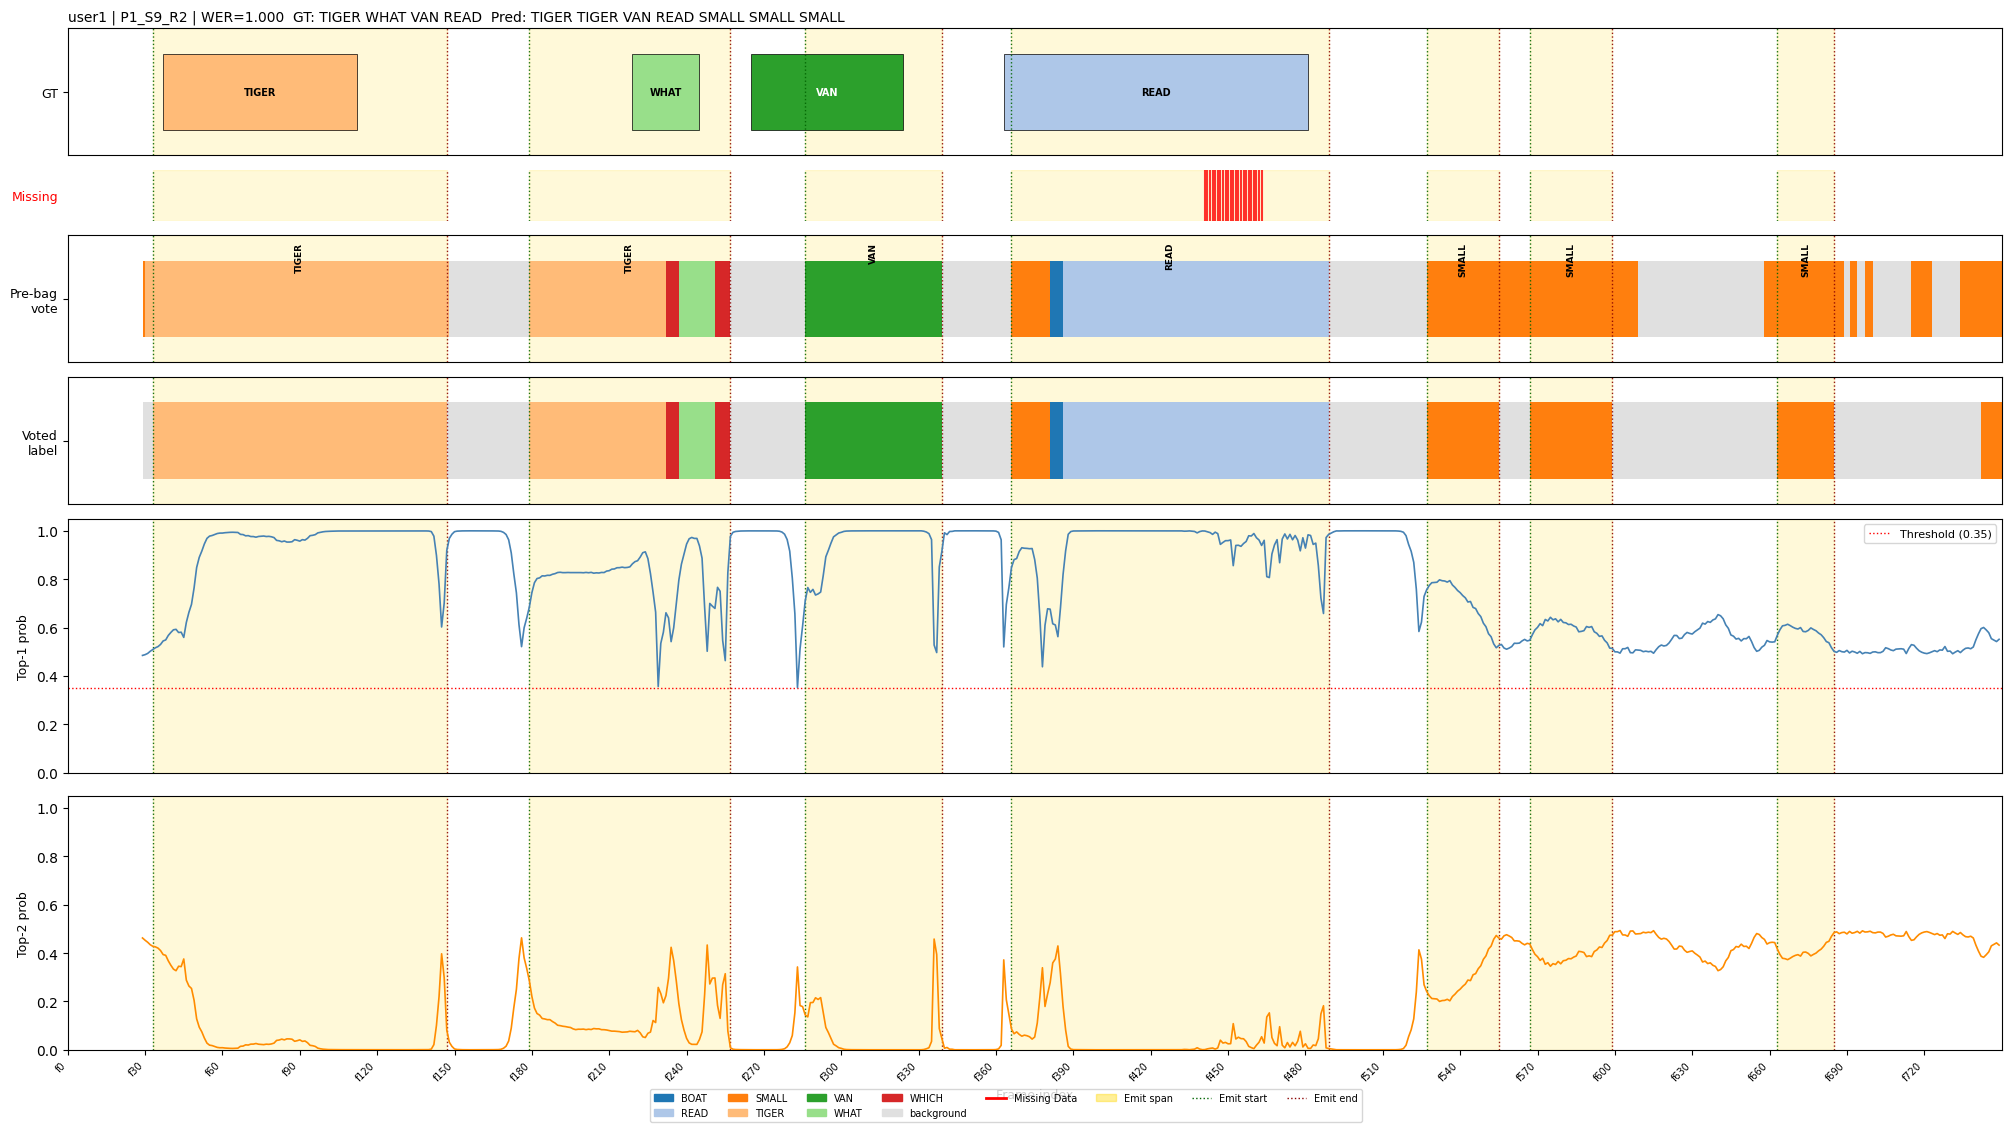

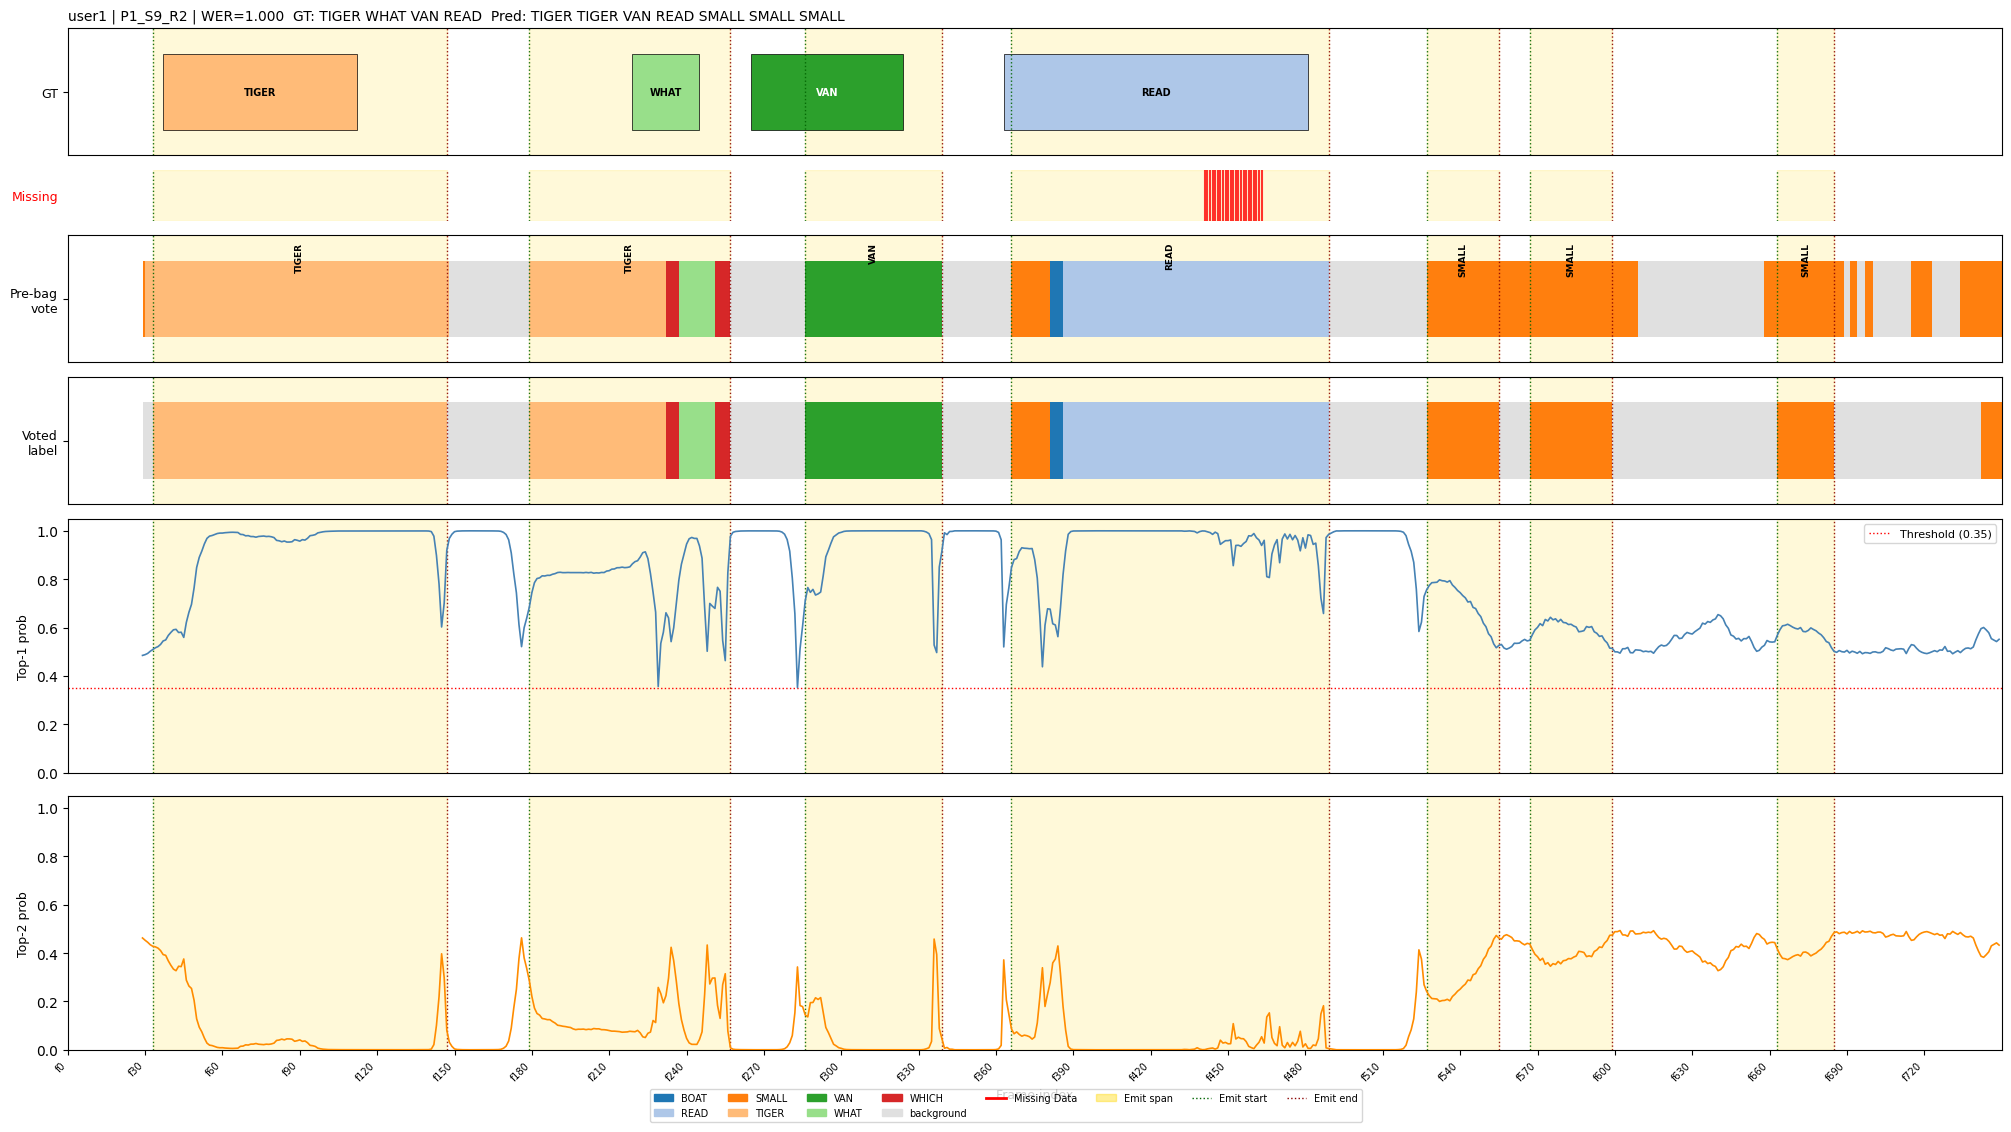

In [40]:
sequence_id = "P1_S9_R2"
user = "user1"
row = test_df.iloc[get_index(test_df, sequence_id)]

# Assuming the base dataset path. You might need to adjust this depending on the notebook's relative path
dataset_root = Path(f"c:/Shoab/Thesis/Experiments/dataset/")
user = row.get('user')  # Assuming this gets you "user1"
csv_path = dataset_root / user / "leap_data" / f"{sequence_id}.csv"

plot_sequence_timeline(row, test_arrays, csv_path=csv_path)


  Top 5 worst sequences — Test
  #1   WER=1.667  user=user1
       id  : P1_S6_R1
       GT  : WHICH OUR TRAIN
       pred: SMALL WHICH SMALL WHICH SMALL OUR TRAIN TRAIN

  #2   WER=1.667  user=user1
       id  : P1_S6_R3
       GT  : WHICH OUR TRAIN
       pred: SMALL SMALL SMALL SMALL TRAIN SMALL

  #3   WER=1.667  user=user1
       id  : P1_S7_R1
       GT  : COME DRIVER BIRD
       pred: SMALL SMALL DRIVER TIGER SMALL SMALL

  #4   WER=1.667  user=user1
       id  : P1_S7_R3
       GT  : COME DRIVER BIRD
       pred: SMALL SMALL SMALL DRIVER TIGER SMALL

  #5   WER=1.333  user=user1
       id  : P1_S4_R1
       GT  : BOAT TRAIN TIGER
       pred: BOAT SMALL SMALL SMALL TIGER TIGER




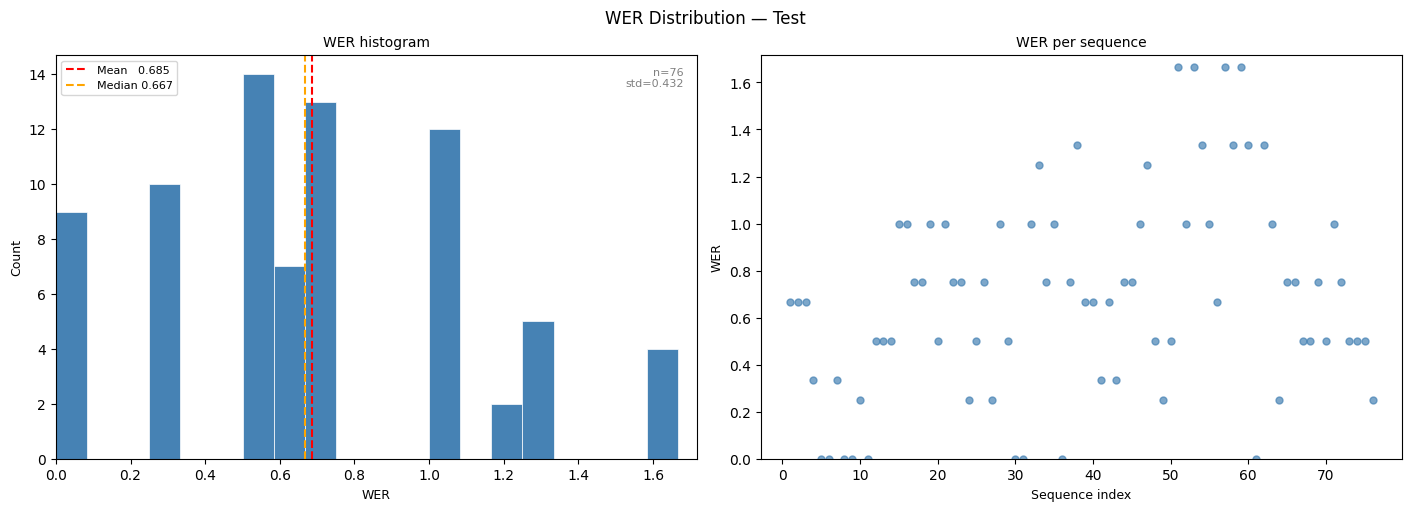

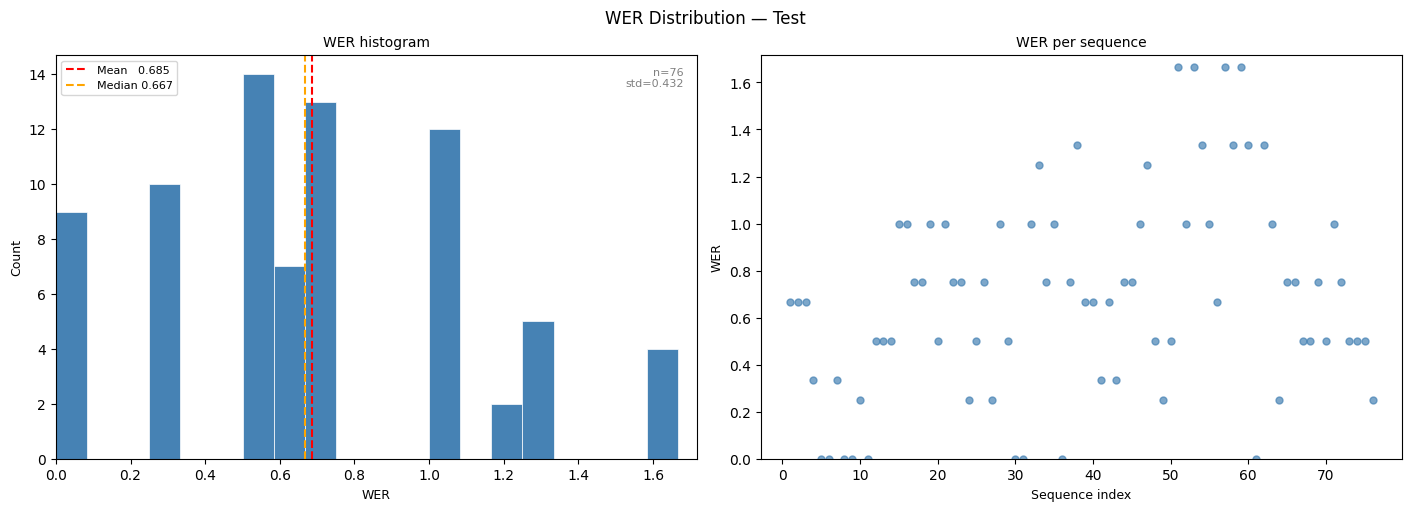

In [41]:
# ============================================================
# Plot 3 — WER distribution for the test split
# ============================================================
plot_wer_distribution(test_df, split_name="Test", top_n_worst=5)

In [14]:
"""
metrics_corrected.py
=====================
Corrected implementation of all three SHREC'21 online gesture recognition
metrics, faithful to the official MATLAB evaluation script (evaluateShrec21.m).

  Caputo et al., "SHREC 2021: Skeleton-based Hand Gesture Recognition
  in the Wild", Computers & Graphics, 2021.
  https://arxiv.org/abs/2106.10980

Fixes applied vs. original AI-generated notebook
---------------------------------------------------
FIX 1 – Detection threshold: overlap/GT_length > 0.5, matching MATLAB
         lines 73-76 exactly (no +1 in overlap).

FIX 2 – Matching loop structure: outer loop over PREDICTIONS, inner loop
         over GT gestures, no break (MATLAB's `break` is commented out,
         so a prediction is checked against every GT annotation, not just
         the first match). `found` lives on the GT side.

FIX 3 – Misclassification tracked separately from False Positive, and is
         NOT gated by `found` (MATLAB increments classResults(...,4)
         unconditionally, even if that GT was already matched by an
         earlier prediction). A misclassified GT instance is also never
         marked `found`, so it additionally gets counted as Missed at the
         end of the sequence — this double bookkeeping is intentional and
         matches MATLAB lines 103-118 + 130-139.

FIX 4 – Jaccard is interval-level (pred-vs-GT pair), not frame-level: for
         every pred/GT pair of the same class with overlap > 0 (regardless
         of whether it clears the 0.5 detection threshold), accumulate
         overlap/union. Matches MATLAB lines 79-83.

FIX 5 – Jaccard denominator: jaccardCounts + Missed + Misclassified + FP,
         matching MATLAB line 141 exactly.

FIX 6 – FPR / Misclass-rate denominator: total GT gestures per class,
         matching the paper's stated formulas.

FIX 7 (REVISED) – FP class attribution now has TWO modes, controlled by
         `replicate_matlab_fp_bug`:
           * True  (default) — reproduces MATLAB's actual behaviour: a
             false positive is filed under the LAST ground-truth
             annotation's class in that sequence (a loop-variable-reuse
             bug in evaluateShrec21.m — `AA` is never reset before being
             used after the inner loop exits). Use this if you want
             numbers that match Table 1 / the official script exactly.
           * False — attributes FP to the class the model actually
             predicted (logically "correct", but NOT what the official
             numbers are built from).
         Previously this file silently did only the "False" behaviour
         while claiming to be "faithful to MATLAB" — that was the bug
         you noticed. Now both are available and the default matches
         MATLAB.

FIX 8 (NEW) – Predictions whose majority-vote frame class is background
         (`None`) are no longer silently dropped. MATLAB has no concept
         of a "blank label" prediction (every submitted triple has an
         explicit class), so this situation only arises from the
         frame-to-interval reconstruction step in `_majority_class`.
         Such predictions are now still counted as a false positive
         (attributed via the same `replicate_matlab_fp_bug` policy — in
         "bug" mode, to the last-GT class; in "clean" mode, to a
         dedicated `_ambiguous` bucket rather than being lost) instead of
         vanishing from every metric.

FIX 9 (NEW) – `_build_pred_intervals` / `_majority_class` now take the
         resolved class count as an explicit argument instead of reading
         the mutable module-level `num_classes`, so a per-call
         `n_classes` override in `evaluate_all` is actually honoured.

SHREC'21 metric definitions (from paper, pooled/micro across all classes)
----------------------------------------------------------------------
  Detection Rate      = sum(TP) / sum(Total GT)
  Misclassification   = sum(Misclassified) / sum(Total GT)
  False Positive Rate = sum(FP) / sum(Total GT)
  Jaccard Index (per class) = sum(overlap/union for matching pairs)
                               / (jaccardCounts + Missed + Misclassified + FP)
  Jaccard Index (reported)  = mean of the per-class Jaccard values
                               (this one genuinely is a macro-average;
                               DR/MR/FPR above are pooled/micro sums, NOT
                               a mean of per-class rates — matching
                               MATLAB's correctScore / misclassifiedRate /
                               falspositiveRate exactly).

Usage
-----
    from metrics_corrected import initialize_globals, evaluate_all, print_global_results

    initialize_globals(n_classes=20)

    for sequence in test_set:
        frame_sequence, y_true, gating_list, y_pred_list = run_model(sequence)
        evaluate_all(frame_sequence, y_true, gating_list, y_pred_list)

    print_global_results(class_names=YOUR_CLASS_LIST)

Inputs
------
  frame_sequence : array-like [s0,e0,s1,e1,...] — GT boundaries (0-based).
  y_true         : list[int] — GT class per gesture instance.
  gating_list    : array-like [s0,e0,s1,e1,...] — predicted boundaries.
  y_pred_list    : list[int] — per-frame predictions (-1 or n_classes = background).
"""

# ---------------------------------------------------------------------------
# Global accumulators
# ---------------------------------------------------------------------------
num_classes = 17

_global_total_gestures      = None
_global_correct_predictions = None
_global_missed              = None
_global_misclassified       = None
_global_false_positives     = None
_global_ambiguous           = None   # FIX 8: FPs with no resolvable class (clean mode only)
_global_latencies           = None
_global_jaccard_sum         = None
_global_jaccard_counts      = None


def initialize_globals(n_classes=17):
    """Reset all global accumulators. Call once before the evaluation loop."""
    global num_classes
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_ambiguous, _global_latencies
    global _global_jaccard_sum, _global_jaccard_counts

    num_classes                 = n_classes
    _global_total_gestures      = [0]   * num_classes
    _global_correct_predictions = [0]   * num_classes
    _global_missed              = [0]   * num_classes
    _global_misclassified       = [0]   * num_classes
    _global_false_positives     = [0]   * num_classes
    _global_ambiguous           = 0
    _global_latencies           = [[]   for _ in range(num_classes)]
    _global_jaccard_sum         = [0.0] * num_classes
    _global_jaccard_counts      = [0]   * num_classes


# ---------------------------------------------------------------------------
# Internal helpers
# ---------------------------------------------------------------------------

def _parse_intervals(flat_list):
    """Convert [s0, e0, s1, e1, ...] into [(s0,e0), (s1,e1), ...]."""
    n = len(flat_list) // 2
    return [(int(flat_list[2 * i]), int(flat_list[2 * i + 1])) for i in range(n)]


def _overlap_ratio(s_true, e_true, s_pred, e_pred):
    """
    FIX 1 — overlap / GT_length, no +1, matching MATLAB lines 73-76.
    A value > 0.5 means the prediction sufficiently covers the GT gesture.
    """
    overlap = min(e_true, e_pred) - max(s_true, s_pred)
    gt_length = e_true - s_true
    if gt_length <= 0:
        gt_length = 1
    return overlap / gt_length


def _majority_class(y_pred_list, s, e, n_classes):
    """
    Most frequent non-background class in y_pred_list[s:e+1].
    Both -1 and n_classes are treated as background and excluded.
    Returns None if every frame is background (FIX 8 handles this
    downstream instead of silently dropping the prediction).

    FIX 9 — n_classes is now an explicit argument, not read from the
    mutable module-level global, so per-call overrides are honoured.
    """
    segment = [
        y_pred_list[i]
        for i in range(s, min(e + 1, len(y_pred_list)))
        if y_pred_list[i] not in (-1, n_classes)
    ]
    if not segment:
        return None
    return max(set(segment), key=segment.count)


def _build_pred_intervals(gating_list, y_pred_list, n_classes):
    """Parse gating_list into [{start, end, class}, ...]. FIX 9: n_classes passed explicitly."""
    intervals = []
    for (s, e) in _parse_intervals(gating_list):
        cls = _majority_class(y_pred_list, s, e, n_classes)
        intervals.append({'start': s, 'end': e, 'class': cls})
    return intervals


# ---------------------------------------------------------------------------
# Core metric computation — matches MATLAB loop structure exactly
# ---------------------------------------------------------------------------

def _compute_metrics(gt_intervals, gt_classes, pred_intervals, n_classes,
                      replicate_matlab_fp_bug=False):
    """
    Compute detection rate, misclassification, FPR, and Jaccard in one pass,
    mirroring the MATLAB script structure:

      outer loop  → predictions  (MATLAB: for r = 1:3:size(R,2))
      inner loop  → GT gestures  (MATLAB: for a = 1:3:size(A,2), no break)
      found[]     → flag on GT side, prevents double-counting a GT as TP

    replicate_matlab_fp_bug (FIX 7):
      True  → false positives are attributed to the class of the LAST
              ground-truth annotation in the sequence, reproducing
              evaluateShrec21.m's loop-variable-reuse bug exactly.
      False → false positives are attributed to the class the model
              actually predicted (logically correct, but diverges from
              the official script's reported numbers).
    """
    total_gestures      = [0]   * n_classes
    correct_predictions = [0]   * n_classes
    missed               = [0]   * n_classes
    misclassified        = [0]   * n_classes
    false_positives       = [0]   * n_classes
    ambiguous_fp          = 0     # FIX 8: only used in "clean" mode
    latencies              = [[]   for _ in range(n_classes)]
    jaccard_sum            = [0.0] * n_classes
    jaccard_counts          = [0]   * n_classes

    num_gt = len(gt_intervals)
    for i in range(num_gt):
        total_gestures[int(gt_classes[i])] += 1

    found = [0] * num_gt

    # FIX 7: precompute the "last GT class in this sequence" — this is what
    # MATLAB's stale `AA` variable evaluates to for every prediction in the
    # sequence (constant across all predictions, since the inner loop always
    # runs to completion with no break).
    last_gt_class = int(gt_classes[-1]) if num_gt > 0 else None

    for pred in pred_intervals:
        s_pred   = pred['start']
        e_pred   = pred['end']
        pred_cls = pred['class']
        detected = False

        for i, (s_true, e_true) in enumerate(gt_intervals):
            true_class = int(gt_classes[i])

            # FIX 4 — Jaccard: any positive overlap with matching label,
            # independent of the 0.5 detection threshold.
            overlap = min(e_true, e_pred) - max(s_true, s_pred)
            if overlap > 0 and pred_cls is not None and pred_cls == true_class:
                u = max(e_true, e_pred) - min(s_true, s_pred)
                if u > 0:
                    jaccard_sum[true_class]    += overlap / u
                    jaccard_counts[true_class] += 1

            # FIX 1 — detection threshold
            ratio = _overlap_ratio(s_true, e_true, s_pred, e_pred)
            if ratio > 0.5:
                detected = True
                if pred_cls is not None and pred_cls == true_class:
                    if found[i] == 0:
                        found[i] = 1
                        correct_predictions[true_class] += 1
                        first_correct = s_pred
                        latencies[true_class].append(max(0, first_correct - s_true))
                else:
                    # FIX 3 — misclassification, unconditional on `found`
                    misclassified[true_class] += 1

        # FIX 7 / FIX 8 — false positive attribution
        if not detected:
            if replicate_matlab_fp_bug:
                # Reproduce MATLAB exactly: attribute to the last GT class
                # in the sequence, even if pred_cls is None or unrelated.
                if last_gt_class is not None:
                    false_positives[last_gt_class] += 1
                # if the sequence has no GT at all, MATLAB's behaviour here
                # is genuinely undefined (stale AA from a previous
                # sequence) — we simply drop it rather than guess.
            else:
                if pred_cls is not None:
                    false_positives[pred_cls] += 1
                else:
                    ambiguous_fp += 1   # FIX 8 — no longer silently lost

    for i in range(num_gt):
        if found[i] == 0:
            missed[int(gt_classes[i])] += 1

    return (total_gestures, correct_predictions, missed,
            misclassified, false_positives, ambiguous_fp, latencies,
            jaccard_sum, jaccard_counts)


# ---------------------------------------------------------------------------
# Main evaluation function — call once per sequence
# ---------------------------------------------------------------------------

def evaluate_all(frame_sequence, y_true, gating_list, y_pred_list,
                  seq_len=None, n_classes=None, verbose=True,
                  replicate_matlab_fp_bug=False):
    """
    Run all metrics for one sequence and update global accumulators.

    replicate_matlab_fp_bug : see _compute_metrics docstring (FIX 7).
    """
    global _global_total_gestures, _global_correct_predictions
    global _global_missed, _global_misclassified, _global_false_positives
    global _global_ambiguous, _global_latencies
    global _global_jaccard_sum, _global_jaccard_counts

    nc = n_classes or num_classes
    if seq_len is None:
        seq_len = len(y_pred_list)

    gt_intervals   = _parse_intervals(frame_sequence)
    pred_intervals = _build_pred_intervals(gating_list, y_pred_list, nc)  # FIX 9

    (total_gest, correct_pred, missed, misclassified,
     false_positives, ambiguous_fp, latencies,
     jaccard_sum, jaccard_counts) = _compute_metrics(
        gt_intervals, y_true, pred_intervals, nc,
        replicate_matlab_fp_bug=replicate_matlab_fp_bug)

    for i in range(nc):
        _global_total_gestures[i]      += total_gest[i]
        _global_correct_predictions[i] += correct_pred[i]
        _global_missed[i]              += missed[i]
        _global_misclassified[i]       += misclassified[i]
        _global_false_positives[i]     += false_positives[i]
        _global_latencies[i].extend(latencies[i])
        _global_jaccard_sum[i]         += jaccard_sum[i]
        _global_jaccard_counts[i]      += jaccard_counts[i]
    _global_ambiguous += ambiguous_fp

    if verbose:
        print("Results for the current sequence:")
        for i in range(nc):
            if total_gest[i] > 0 or false_positives[i] > 0:
                dr  = correct_pred[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                mr  = misclassified[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                fpr = false_positives[i] / total_gest[i] if total_gest[i] > 0 else 0.0
                jac_denom = jaccard_counts[i] + missed[i] + misclassified[i] + false_positives[i]
                avg_jac   = jaccard_sum[i] / jac_denom if jac_denom > 0 else 0.0
                print(f"  Class {i}: DR={dr:.2f}  MR={mr:.2f}  FPR={fpr:.2f}  Jaccard={avg_jac:.3f}")
        if ambiguous_fp:
            print(f"  (ambiguous / all-background predictions this sequence: {ambiguous_fp})")
        print()


# ---------------------------------------------------------------------------
# Print global results — call after all sequences are processed
# ---------------------------------------------------------------------------

def print_global_results(class_names=None):
    """
    DR / Misclass / FPR below are POOLED (micro) sums across all classes,
    matching MATLAB's correctScore / misclassifiedRate / falspositiveRate
    exactly — NOT a mean of per-class rates. Jaccard genuinely is a mean
    of per-class averages, matching how Table 1 in the paper reports it.
    """
    nc = num_classes
    print("=" * 60)
    print("GLOBAL RESULTS  (Corrected — SHREC'21 protocol)")
    print("=" * 60)

    total_tp, total_gt, total_fp, total_misc = 0, 0, 0, 0
    all_jac = []

    for i in range(nc):
        gt   = _global_total_gestures[i]
        tp   = _global_correct_predictions[i]
        miss = _global_missed[i]
        misc = _global_misclassified[i]
        fp   = _global_false_positives[i]
        j_sum = _global_jaccard_sum[i]
        j_cnt = _global_jaccard_counts[i]

        if gt == 0 and fp == 0:
            continue

        name = class_names[i] if class_names else str(i)
        dr   = tp   / gt if gt > 0 else 0.0
        mr   = misc / gt if gt > 0 else 0.0
        fpr  = fp   / gt if gt > 0 else 0.0
        avg_lat = (sum(_global_latencies[i]) / len(_global_latencies[i])
                   if _global_latencies[i] else float('nan'))

        jac_denom = j_cnt + miss + misc + fp
        avg_jac   = j_sum / jac_denom if jac_denom > 0 else 0.0

        print(f"Class {name}:")
        print(f"  Detection Rate : {dr:.4f}  ({tp}/{gt})")
        print(f"  Misclass Rate  : {mr:.4f}  ({misc}/{gt})")
        print(f"  False Pos Rate : {fpr:.4f}  ({fp} FP / {gt} GT)")
        print(f"  Avg Latency    : {avg_lat:.2f} frames")
        print(f"  Avg Jaccard    : {avg_jac:.4f}")

        total_tp += tp; total_gt += gt; total_fp += fp; total_misc += misc
        all_jac.append(avg_jac)

    print()
    print("--- Pooled (micro) rates + macro-averaged Jaccard ---")
    pooled_dr  = total_tp   / total_gt if total_gt > 0 else 0.0
    pooled_mr  = total_misc / total_gt if total_gt > 0 else 0.0
    pooled_fpr = total_fp   / total_gt if total_gt > 0 else 0.0
    macro_jac  = sum(all_jac) / len(all_jac) if all_jac else float('nan')
    print(f"  Detection Rate : {pooled_dr:.4f}")
    print(f"  Misclass Rate  : {pooled_mr:.4f}")
    print(f"  False Pos Rate : {pooled_fpr:.4f}")
    print(f"  Jaccard Index  : {macro_jac:.4f}")
    if _global_ambiguous:
        print(f"  Ambiguous (all-background) predictions dropped: {_global_ambiguous}")
    print("=" * 60)


# ---------------------------------------------------------------------------
# Sanity check
# ---------------------------------------------------------------------------

if __name__ == "__main__":
    N_CLASSES = 5
    SEQ_LEN   = 200

    frame_seq  = [10, 40, 70, 100, 130, 160]
    y_true_seq = [0, 1, 2]

    y_pred = [-1] * SEQ_LEN
    for f in range(12, 38):   y_pred[f] = 0
    for f in range(75, 98):   y_pred[f] = 1
    for f in range(140, 165): y_pred[f] = 3   # wrong class → misclassification

    gating = [11, 38, 74, 99, 139, 166]

    print(">>> MODE: replicate_matlab_fp_bug=True (matches official script)")
    initialize_globals(n_classes=N_CLASSES)
    evaluate_all(frame_seq, y_true_seq, gating, y_pred, seq_len=SEQ_LEN,
                 verbose=True, replicate_matlab_fp_bug=True)
    print_global_results(class_names=["A", "B", "C", "D", "E"])

    print("\n>>> MODE: replicate_matlab_fp_bug=False (logically-correct attribution)")
    initialize_globals(n_classes=N_CLASSES)
    evaluate_all(frame_seq, y_true_seq, gating, y_pred, seq_len=SEQ_LEN,
                 verbose=True, replicate_matlab_fp_bug=False)
    print_global_results(class_names=["A", "B", "C", "D", "E"])

>>> MODE: replicate_matlab_fp_bug=True (matches official script)
Results for the current sequence:
  Class 0: DR=1.00  MR=0.00  FPR=0.00  Jaccard=0.900
  Class 1: DR=1.00  MR=0.00  FPR=0.00  Jaccard=0.833
  Class 2: DR=0.00  MR=1.00  FPR=0.00  Jaccard=0.000

GLOBAL RESULTS  (Corrected — SHREC'21 protocol)
Class A:
  Detection Rate : 1.0000  (1/1)
  Misclass Rate  : 0.0000  (0/1)
  False Pos Rate : 0.0000  (0 FP / 1 GT)
  Avg Latency    : 1.00 frames
  Avg Jaccard    : 0.9000
Class B:
  Detection Rate : 1.0000  (1/1)
  Misclass Rate  : 0.0000  (0/1)
  False Pos Rate : 0.0000  (0 FP / 1 GT)
  Avg Latency    : 4.00 frames
  Avg Jaccard    : 0.8333
Class C:
  Detection Rate : 0.0000  (0/1)
  Misclass Rate  : 1.0000  (1/1)
  False Pos Rate : 0.0000  (0 FP / 1 GT)
  Avg Latency    : nan frames
  Avg Jaccard    : 0.0000

--- Pooled (micro) rates + macro-averaged Jaccard ---
  Detection Rate : 0.6667
  Misclass Rate  : 0.3333
  False Pos Rate : 0.0000
  Jaccard Index  : 0.5778

>>> MODE: repli

In [15]:

init_corr = initialize_globals
eval_all_corr = evaluate_all
print_corr = print_global_results



In [16]:
BAG_SIZE = 5
BAG_AGGREGATION = "mean"
CONFIDENCE_THRESHOLD = 0.35
SIGN_BG_MARGIN = 0.10
LEAP_FPS = 30
MIN_SIGN_MS = 500
MIN_SIGN_FRAMES = max(1, int(round((MIN_SIGN_MS / 1000.0) * LEAP_FPS)))

In [17]:

from __future__ import annotations

from collections import Counter, deque





# ---------------------------------------------------------------------------
# Bag aggregator — unchanged from notebook
# ---------------------------------------------------------------------------
# ... [Keeping class _BagAggregator and SimplifiedBagDecoder unchanged] ...
# [Just replace the stream_model_online function at the bottom]



# ---------------------------------------------------------------------------
# Bag aggregator — unchanged from notebook
# ---------------------------------------------------------------------------

class _BagAggregator:
    """
    Causal sliding bag over raw logits.

    Why logits and not probs:
        Averaging in logit space is equivalent to a product-of-experts,
        which is sharper and more discriminative than averaging softmax probs.
        Converting to probs happens once after aggregation.

    Modes
    -----
    mean      : arithmetic mean of per-window probs after softmax
    max       : element-wise max of per-window probs
    attention : recency-weighted mean, most recent window weighted highest
    """

    def __init__(self, bag_size: int, aggregation: str, num_classes: int):
        self.bag_size    = max(1, int(bag_size))
        self.aggregation = aggregation
        self.num_classes = num_classes
        self._buffer     = deque(maxlen=self.bag_size)

    def update(self, logits: np.ndarray) -> np.ndarray | None:
        """
        Push one logit vector and return aggregated probs.

        Returns None until bag is full (first bag_size frames are skipped).
        """
        self._buffer.append(logits.copy())

        if len(self._buffer) < self.bag_size:
            return None

        bag         = np.stack(self._buffer, axis=0)           # (bag_size, C)
        bag_shifted = bag - bag.max(axis=-1, keepdims=True)
        exp_bag     = np.exp(bag_shifted)
        probs       = exp_bag / exp_bag.sum(axis=-1, keepdims=True)  # (bag_size, C)

        if self.aggregation == "mean":
            return probs.mean(axis=0)

        if self.aggregation == "max":
            return probs.max(axis=0)

        if self.aggregation == "attention":
            weights  = np.linspace(0.5, 1.0, len(self._buffer))
            weights /= weights.sum()
            return (probs * weights[:, np.newaxis]).sum(axis=0)

        raise ValueError(f"Unknown aggregation mode: {self.aggregation}")

    def reset(self):
        self._buffer.clear()


# ---------------------------------------------------------------------------
# Simplified streaming decoder — unchanged from notebook
# ---------------------------------------------------------------------------

class SimplifiedBagDecoder:
    """
    Causal streaming decoder using bag-aggregated logits.

    States
    ------
    SEEKING : waiting for a sign to begin
    IN_SIGN : inside an active sign region, accumulating votes

    Emission
    --------
    Fires at the TRAILING edge when the bag transitions to background.
    Emits the majority label observed across the entire region.
    Discards regions shorter than min_sign_frames (noise / glitches).

    Storage additions vs original
    -----------------------------
    pre_bag_logits     : raw logits from model before bag, stored per frame
    post_bag_probs     : aggregated probability vector after bag, stored per frame
                         None for first (bag_size - 1) frames until bag is full
    emit_region        : (start_frame, end_frame, label) on emission, else None
    region_start_frame : frame index where current IN_SIGN region began
    """

    def __init__(
        self,
        id_to_label: dict[int, str],
        background_label: str,
        bag_size: int               = BAG_SIZE,
        aggregation: str            = BAG_AGGREGATION,
        confidence_threshold: float = CONFIDENCE_THRESHOLD,
        sign_bg_margin: float       = SIGN_BG_MARGIN,
        min_sign_frames: int        = MIN_SIGN_FRAMES,
    ):
        self.id_to_label          = id_to_label
        self.background_label     = background_label
        self.confidence_threshold = float(confidence_threshold)
        self.sign_bg_margin       = float(sign_bg_margin)
        self.min_sign_frames      = max(1, int(min_sign_frames))

        self.background_id = next(
            (k for k, v in id_to_label.items() if v == background_label), None
        )

        self._bag = _BagAggregator(bag_size, aggregation, len(id_to_label))

        # Hysteresis state
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None      # frame where current IN_SIGN region began

    # ------------------------------------------------------------------

    def _gate(self, agg_probs: np.ndarray):
        """
        Apply confidence gate to aggregated probabilities.

        Returns
        -------
        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs
        agg_probs passed through so caller can store it as post_bag_probs
        without recomputing.
        """
        pred_id    = int(np.argmax(agg_probs))
        pred_label = self.id_to_label.get(pred_id, f"sign_{pred_id}")
        pred_conf  = float(agg_probs[pred_id])
        bg_conf    = (
            float(agg_probs[self.background_id])
            if self.background_id is not None else 0.0
        )

        is_sign = (
            pred_label != self.background_label
            and pred_conf  >= self.confidence_threshold
            and (pred_conf - bg_conf) >= self.sign_bg_margin
        )

        voted_label   = pred_label if is_sign else self.background_label
        is_background = not is_sign

        return voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs

    # ------------------------------------------------------------------

    def update(self, logits: np.ndarray, frame_index: int) -> dict:
        """
        Process one frame.

        Parameters
        ----------
        logits      : (C,) raw logits from model — stored as pre_bag_logits
        frame_index : int current frame index, needed for emit_region tracking

        Returns
        -------
        dict containing:
            raw_label      : top-1 label from pre-bag logits
            raw_conf       : top-1 confidence from pre-bag logits
            bg_conf        : background confidence from post-bag probs (0 until bag full)
            gated_label    : label after confidence gate (post-bag)
            voted_label    : same as gated_label
            state          : decoder state after this step (SEEKING / IN_SIGN)
            emitted_label  : emitted sign label if trailing edge fired, else None
            emit_region    : (start_frame, end_frame, label) on emission, else None
            pre_bag_logits : (C,) raw logits before bag — for visualization
            post_bag_probs : (C,) aggregated probs after bag — for visualization
                             None for first (bag_size - 1) frames
        """
        pre_bag_logits = logits.copy()              # capture before bag sees it
        agg_probs      = self._bag.update(logits)

        # Bag not full yet — stay in SEEKING, emit nothing
        if agg_probs is None:
            raw_probs = np.exp(logits - logits.max())
            raw_probs /= raw_probs.sum()
            return {
                "raw_label":      self.id_to_label.get(int(np.argmax(logits)), "?"),
                "raw_conf":       float(raw_probs.max()),
                "bg_conf":        0.0,
                "gated_label":    self.background_label,
                "voted_label":    self.background_label,
                "state":          self.state,
                "emitted_label":  None,
                "emit_region":    None,
                "pre_bag_logits": pre_bag_logits,   # (C,) always stored
                "post_bag_probs": None,             # bag not full yet
            }

        voted_label, is_background, pred_label, pred_conf, bg_conf, agg_probs = \
            self._gate(agg_probs)

        emitted_label = None
        emit_region   = None

        if self.state == "SEEKING":
            if not is_background:
                self.state              = "IN_SIGN"
                self.region_votes[voted_label] += 1
                self.sign_frames        = 1
                self.region_start_frame = frame_index   # record region start

        elif self.state == "IN_SIGN":
            if not is_background:
                self.region_votes[voted_label] += 1
                self.sign_frames += 1
            else:
                # Bag confirmed background — trailing edge reached
                if self.sign_frames >= self.min_sign_frames:
                    emitted_label = self.region_votes.most_common(1)[0][0]
                    emit_region   = (
                        self.region_start_frame,    # start of region
                        frame_index,                # end of region (trailing edge)
                        emitted_label,
                    )
                # else: region too short → discard silently

                self.state              = "SEEKING"
                self.region_votes       = Counter()
                self.sign_frames        = 0
                self.region_start_frame = None

        return {
            "raw_label":      pred_label,
            "raw_conf":       pred_conf,
            "bg_conf":        bg_conf,
            "gated_label":    voted_label,
            "voted_label":    voted_label,
            "state":          self.state,
            "emitted_label":  emitted_label,
            "emit_region":    emit_region,          # (start, end, label) or None
            "pre_bag_logits": pre_bag_logits,       # (C,) raw pre-bag logits
            "post_bag_probs": agg_probs,            # (C,) post-bag aggregated probs
        }

    # ------------------------------------------------------------------

    def flush(self) -> tuple[str | None, tuple | None]:
        """
        Call once after all frames are processed.

        Emits any sign region still open at sequence end.
        Necessary when a sequence ends without returning to background.

        Returns
        -------
        (emitted_label, emit_region)
        emit_region end frame is None — caller fills with t_len - 1.
        """
        emitted     = None
        emit_region = None

        if self.state == "IN_SIGN" and self.sign_frames >= self.min_sign_frames:
            emitted     = self.region_votes.most_common(1)[0][0]
            emit_region = (
                self.region_start_frame,
                None,       # end unknown — caller fills with t_len - 1
                emitted,
            )

        # Always reset — decoder is invalid after flush
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None
        self._bag.reset()

        return emitted, emit_region


In [18]:
from __future__ import annotations

from collections import Counter, deque


# ---------------------------------------------------------------------------
# Bag aggregator — unchanged from notebook
# ---------------------------------------------------------------------------

class _BagAggregator:
    """
    Causal sliding bag over raw logits.

    Why logits and not probs:
        Averaging in logit space is equivalent to a product-of-experts,
        which is sharper and more discriminative than averaging softmax probs.
        Converting to probs happens once after aggregation.

    Modes
    -----
    mean      : arithmetic mean of per-window probs after softmax
    max       : element-wise max of per-window probs
    attention : recency-weighted mean, most recent window weighted highest
    """

    def __init__(self, bag_size: int, aggregation: str, num_classes: int):
        self.bag_size    = max(1, int(bag_size))
        self.aggregation = aggregation
        self.num_classes = num_classes
        self._buffer     = deque(maxlen=self.bag_size)

    def update(self, logits: np.ndarray) -> np.ndarray | None:
        """
        Push one logit vector and return aggregated probs.

        Returns None until bag is full (first bag_size frames are skipped).
        """
        self._buffer.append(logits.copy())

        if len(self._buffer) < self.bag_size:
            return None

        bag         = np.stack(self._buffer, axis=0)           # (bag_size, C)
        bag_shifted = bag - bag.max(axis=-1, keepdims=True)
        exp_bag     = np.exp(bag_shifted)
        probs       = exp_bag / exp_bag.sum(axis=-1, keepdims=True)  # (bag_size, C)

        if self.aggregation == "mean":
            return probs.mean(axis=0)

        if self.aggregation == "max":
            return probs.max(axis=0)

        if self.aggregation == "attention":
            weights  = np.linspace(0.5, 1.0, len(self._buffer))
            weights /= weights.sum()
            return (probs * weights[:, np.newaxis]).sum(axis=0)

        raise ValueError(f"Unknown aggregation mode: {self.aggregation}")

    def reset(self):
        self._buffer.clear()


# ---------------------------------------------------------------------------
# Streaming decoder — exit patience + asymmetric entry/exit thresholds added
# ---------------------------------------------------------------------------

class SimplifiedBagDecoder:
    """
    Causal streaming decoder using bag-aggregated logits.

    States
    ------
    SEEKING : waiting for a sign to begin
    IN_SIGN : inside an active sign region, accumulating votes

    Emission
    --------
    Fires once the bag has stayed in background for `exit_patience`
    consecutive frames (trailing-edge confirmation, not a single-frame cut).
    Emits the majority label observed across the entire region.
    Discards regions shorter than min_sign_frames (noise / glitches).

    Entry vs exit gating (Schmitt-trigger style)
    ---------------------------------------------
    Starting a region uses the strict entry thresholds
    (confidence_threshold, sign_bg_margin) to avoid false starts.
    Staying in a region uses the looser exit thresholds
    (exit_confidence_threshold, exit_sign_bg_margin) so a normal
    mid-gesture confidence dip doesn't get misread as background.
    Exit thresholds should be <= entry thresholds.

    Exit patience
    --------------
    A single background-gated frame while IN_SIGN no longer closes the
    region. A streak of `exit_patience` consecutive background-gated
    frames is required. If a sign-gated frame reappears before the
    streak completes, the streak resets and the region stays open —
    those grace-period frames are not counted as votes either way.
    The emitted region's end frame is backdated to the first frame of
    the confirmed background streak (the true sign/background boundary),
    not the frame where the streak was confirmed.

    Storage additions vs original
    -----------------------------
    pre_bag_logits     : raw logits from model before bag, stored per frame
    post_bag_probs     : aggregated probability vector after bag, stored per frame
                         None for first (bag_size - 1) frames until bag is full
    emit_region        : (start_frame, end_frame, label) on emission, else None
    region_start_frame : frame index where current IN_SIGN region began
    """

    def __init__(
        self,
        id_to_label: dict[int, str],
        background_label: str,
        bag_size: int                      = BAG_SIZE,
        aggregation: str                   = BAG_AGGREGATION,
        confidence_threshold: float        = CONFIDENCE_THRESHOLD,
        sign_bg_margin: float              = SIGN_BG_MARGIN,
        min_sign_frames: int               = MIN_SIGN_FRAMES,
        exit_confidence_threshold: float | None = None,
        exit_sign_bg_margin: float | None       = None,
        exit_patience: int                      = 3,
    ):
        self.id_to_label          = id_to_label
        self.background_label     = background_label
        self.confidence_threshold = float(confidence_threshold)
        self.sign_bg_margin       = float(sign_bg_margin)
        self.min_sign_frames      = max(1, int(min_sign_frames))

        # Exit thresholds default to a looser fraction of the entry thresholds
        # if not explicitly provided — keeps old call sites working unchanged
        # while still getting the Schmitt-trigger behavior out of the box.
        self.exit_confidence_threshold = float(
            exit_confidence_threshold
            if exit_confidence_threshold is not None
            else self.confidence_threshold * 0.75
        )
        self.exit_sign_bg_margin = float(
            exit_sign_bg_margin
            if exit_sign_bg_margin is not None
            else self.sign_bg_margin * 0.5
        )
        self.exit_patience = max(1, int(exit_patience))

        self.background_id = next(
            (k for k, v in id_to_label.items() if v == background_label), None
        )

        self._bag = _BagAggregator(bag_size, aggregation, len(id_to_label))

        # Hysteresis state
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None      # frame where current IN_SIGN region began
        self._bg_streak         = 0         # consecutive background-gated frames while IN_SIGN

    # ------------------------------------------------------------------

    def _classify(self, agg_probs: np.ndarray):
        """
        Pure top-1 / background readout from aggregated probs.
        No thresholding here — that's decided by the caller, since entry
        and exit use different thresholds.
        """
        pred_id    = int(np.argmax(agg_probs))
        pred_label = self.id_to_label.get(pred_id, f"sign_{pred_id}")
        pred_conf  = float(agg_probs[pred_id])
        bg_conf    = (
            float(agg_probs[self.background_id])
            if self.background_id is not None else 0.0
        )
        return pred_label, pred_conf, bg_conf

    @staticmethod
    def _is_sign(pred_label, pred_conf, bg_conf, background_label, threshold, margin):
        return (
            pred_label != background_label
            and pred_conf  >= threshold
            and (pred_conf - bg_conf) >= margin
        )

    # ------------------------------------------------------------------

    def update(self, logits: np.ndarray, frame_index: int) -> dict:
        """
        Process one frame.

        Parameters
        ----------
        logits      : (C,) raw logits from model — stored as pre_bag_logits
        frame_index : int current frame index, needed for emit_region tracking

        Returns
        -------
        dict containing:
            raw_label      : top-1 label from pre-bag logits
            raw_conf       : top-1 confidence from pre-bag logits
            bg_conf        : background confidence from post-bag probs (0 until bag full)
            gated_label    : label after confidence gate (post-bag)
            voted_label    : same as gated_label
            state          : decoder state after this step (SEEKING / IN_SIGN)
            emitted_label  : emitted sign label if trailing edge fired, else None
            emit_region    : (start_frame, end_frame, label) on emission, else None
            pre_bag_logits : (C,) raw logits before bag — for visualization
            post_bag_probs : (C,) aggregated probs after bag — for visualization
                             None for first (bag_size - 1) frames
        """
        pre_bag_logits = logits.copy()              # capture before bag sees it
        agg_probs      = self._bag.update(logits)

        # Bag not full yet — stay in SEEKING, emit nothing
        if agg_probs is None:
            raw_probs = np.exp(logits - logits.max())
            raw_probs /= raw_probs.sum()
            return {
                "raw_label":      self.id_to_label.get(int(np.argmax(logits)), "?"),
                "raw_conf":       float(raw_probs.max()),
                "bg_conf":        0.0,
                "gated_label":    self.background_label,
                "voted_label":    self.background_label,
                "state":          self.state,
                "emitted_label":  None,
                "emit_region":    None,
                "pre_bag_logits": pre_bag_logits,   # (C,) always stored
                "post_bag_probs": None,             # bag not full yet
            }

        pred_label, pred_conf, bg_conf = self._classify(agg_probs)

        # Entry vs exit thresholds depend on current state
        if self.state == "SEEKING":
            is_sign = self._is_sign(
                pred_label, pred_conf, bg_conf, self.background_label,
                self.confidence_threshold, self.sign_bg_margin,
            )
        else:  # IN_SIGN
            is_sign = self._is_sign(
                pred_label, pred_conf, bg_conf, self.background_label,
                self.exit_confidence_threshold, self.exit_sign_bg_margin,
            )

        voted_label   = pred_label if is_sign else self.background_label
        is_background = not is_sign

        emitted_label = None
        emit_region   = None

        if self.state == "SEEKING":
            if not is_background:
                self.state              = "IN_SIGN"
                self.region_votes[voted_label] += 1
                self.sign_frames        = 1
                self.region_start_frame = frame_index   # record region start
                self._bg_streak         = 0

        elif self.state == "IN_SIGN":
            if not is_background:
                self.region_votes[voted_label] += 1
                self.sign_frames += 1
                self._bg_streak = 0   # sign resumed — cancel any pending exit
            else:
                self._bg_streak += 1

                if self._bg_streak >= self.exit_patience:
                    # Background streak confirmed — trailing edge reached.
                    # Backdate the end to the first frame of the streak,
                    # i.e. the true sign/background boundary.
                    if self.sign_frames >= self.min_sign_frames:
                        emitted_label = self.region_votes.most_common(1)[0][0]
                        emit_region   = (
                            self.region_start_frame,
                            frame_index - self.exit_patience + 1,
                            emitted_label,
                        )
                    # else: region too short → discard silently

                    self.state              = "SEEKING"
                    self.region_votes       = Counter()
                    self.sign_frames        = 0
                    self.region_start_frame = None
                    self._bg_streak         = 0
                # else: still within grace period — stay IN_SIGN, emit nothing,
                # and don't count this frame as a vote either way.

        return {
            "raw_label":      pred_label,
            "raw_conf":       pred_conf,
            "bg_conf":        bg_conf,
            "gated_label":    voted_label,
            "voted_label":    voted_label,
            "state":          self.state,
            "emitted_label":  emitted_label,
            "emit_region":    emit_region,          # (start, end, label) or None
            "pre_bag_logits": pre_bag_logits,       # (C,) raw pre-bag logits
            "post_bag_probs": agg_probs,            # (C,) post-bag aggregated probs
        }

    # ------------------------------------------------------------------

    def flush(self) -> tuple[str | None, tuple | None]:
        """
        Call once after all frames are processed.

        Emits any sign region still open at sequence end.
        Necessary when a sequence ends without returning to background.

        Returns
        -------
        (emitted_label, emit_region)
        emit_region end frame is None — caller fills with t_len - 1.
        """
        emitted     = None
        emit_region = None

        if self.state == "IN_SIGN" and self.sign_frames >= self.min_sign_frames:
            emitted     = self.region_votes.most_common(1)[0][0]
            emit_region = (
                self.region_start_frame,
                None,       # end unknown — caller fills with t_len - 1
                emitted,
            )

        # Always reset — decoder is invalid after flush
        self.state              = "SEEKING"
        self.region_votes       = Counter()
        self.sign_frames        = 0
        self.region_start_frame = None
        self._bg_streak         = 0
        self._bag.reset()

        return emitted, emit_region

In [42]:


# Your class mappings
id_to_label = {
    0: "AUGUST", 1: "BIG", 2: "BIRD", 3: "BOAT", 4: "COME", 5: "DRIVER",
    6: "FARMING", 7: "FEBRUARY", 8: "GO", 9: "GREETINGS", 10: "OUR",
    11: "READ", 12: "SMALL", 13: "TIGER", 14: "TRAIN", 15: "UGLY",
    16: "VAN", 17: "WHAT", 18: "WHICH", 19: "WRITE", 20: "background",
}
label_to_id = {v: k for k, v in id_to_label.items()}
num_classes = len(id_to_label)
class_names = [id_to_label[i] for i in range(num_classes)]


def evaluate_metrics_per_user_from_pre_bag(df: pd.DataFrame, arrays: dict, split_name: str):
    """Evaluates SHREC'21 streaming metrics per user by re-decoding from pre-bag logits."""
    for user, user_df in df.groupby("user"):
        print(f"\n{'='*60}")
        print(f"USER: {user} — Split: {split_name}")
        print(f"{'='*60}")
        
        # Reset global accumulators for the corrected metrics for this user
        init_corr(n_classes=num_classes)
        cnt = 1
        for _, row in user_df.iterrows():
            seq_arrays = get_sequence_arrays(row, arrays)
            if not seq_arrays or seq_arrays.get("pre_bag_logits") is None:
                continue
            
            pre_bag_logits = seq_arrays["pre_bag_logits"]
            frame_indices = seq_arrays["frame_indices"]
            
            seq_len = int(row["num_frames"])
            
            # Initialize a fresh decoder for this sequence
            decoder = SimplifiedBagDecoder(
                id_to_label=id_to_label,
                background_label=BACKGROUND_LABEL,
                bag_size=BAG_SIZE,
                aggregation=BAG_AGGREGATION,
                confidence_threshold=CONFIDENCE_THRESHOLD,
                sign_bg_margin=SIGN_BG_MARGIN,
                min_sign_frames=MIN_SIGN_FRAMES,
            )
            
            y_pred_list = [-1] * seq_len
            gating_list = []
            bg_id = label_to_id.get(BACKGROUND_LABEL)
            
            # Process frames in order to re-apply bag and gating
            for i in range(len(pre_bag_logits)):
                fi = int(frame_indices[i])
                if fi < 0 or fi >= seq_len:
                    continue
                
                # Feed raw pre-bag logits to the decoder state machine
                decoded = decoder.update(pre_bag_logits[i], frame_index=fi)
                
                # Track per-frame predictions
                voted_label_str = decoded.get("voted_label", BACKGROUND_LABEL)
                if voted_label_str != BACKGROUND_LABEL:
                    cls_id = label_to_id.get(voted_label_str)
                    if cls_id is not None and cls_id != bg_id:
                        y_pred_list[fi] = cls_id
                        
                # Track emit regions
                if decoded.get("emit_region") is not None:
                    start, end, _ = decoded["emit_region"]
                    gating_list.append(int(start))
                    gating_list.append(int(end))
            
            # Flush the decoder for any trailing open signs
            final_emission, final_emit_region = decoder.flush()
            if final_emission is not None and final_emit_region is not None:
                start, _, _ = final_emit_region
                gating_list.append(int(start))
                gating_list.append(seq_len - 1)
            
            # Build GT arrays from the gt_segments stored in metadata
            frame_sequence = []
            y_true = []
            gt_segments = row.get("gt_segments", [])
            
            for seg in gt_segments:
                # seg is expected to be a tuple: (start_frame, end_frame, label_str)
                if len(seg) < 3:
                    continue
                start, end, label_str = seg[0], seg[1], str(seg[2])
                if label_str == BACKGROUND_LABEL:
                    continue
                cls_id = label_to_id.get(label_str)
                if cls_id is None:
                    continue
                frame_sequence.append(int(start))
                frame_sequence.append(int(end))
                y_true.append(cls_id)
                
            if len(y_true) == 0:
                continue
                
            # Compute metrics for this sequence and accumulate globally for the user
            eval_all_corr(
                frame_sequence, y_true, gating_list, y_pred_list,
                seq_len=seq_len, n_classes=num_classes, verbose=False
            )
        
        # Print the aggregated results for this user
        print_corr(class_names=class_names)


# ============================================================
# Load and evaluate
# ============================================================
TEST_SPLIT = "test_user1_20260630t195849z"
VAL_SPLIT  = "val_user1_20260630t195849z"

# Load test split
test_df, test_arrays = load_split_results(TEST_SPLIT)
evaluate_metrics_per_user_from_pre_bag(test_df, test_arrays, "Test")

# Load val split (optional)
# val_df, val_arrays = load_split_results(VAL_SPLIT)
# evaluate_metrics_per_user_from_pre_bag(val_df, val_arrays, "Validation")


USER: user1 — Split: Test
GLOBAL RESULTS  (Corrected — SHREC'21 protocol)
Class AUGUST:
  Detection Rate : 1.0000  (13/13)
  Misclass Rate  : 0.0000  (0/13)
  False Pos Rate : 0.0000  (0 FP / 13 GT)
  Avg Latency    : 2.77 frames
  Avg Jaccard    : 0.8167
Class BIG:
  Detection Rate : 0.5625  (9/16)
  Misclass Rate  : 0.4375  (7/16)
  False Pos Rate : 0.0000  (0 FP / 16 GT)
  Avg Latency    : 18.00 frames
  Avg Jaccard    : 0.2034
Class BIRD:
  Detection Rate : 0.4615  (6/13)
  Misclass Rate  : 0.0000  (0/13)
  False Pos Rate : 0.3846  (5 FP / 13 GT)
  Avg Latency    : 13.50 frames
  Avg Jaccard    : 0.2549
Class BOAT:
  Detection Rate : 1.0000  (13/13)
  Misclass Rate  : 0.0000  (0/13)
  False Pos Rate : 0.0000  (0 FP / 13 GT)
  Avg Latency    : 2.62 frames
  Avg Jaccard    : 0.6761
Class COME:
  Detection Rate : 0.4286  (6/14)
  Misclass Rate  : 0.5000  (7/14)
  False Pos Rate : 0.0000  (0 FP / 14 GT)
  Avg Latency    : 10.67 frames
  Avg Jaccard    : 0.1942
Class DRIVER:
  Detectio

In [20]:



# Your class mappings
id_to_label = {
    0: "AUGUST", 1: "BIG", 2: "BIRD", 3: "BOAT", 4: "COME", 5: "DRIVER",
    6: "FARMING", 7: "FEBRUARY", 8: "GO", 9: "GREETINGS", 10: "OUR",
    11: "READ", 12: "SMALL", 13: "TIGER", 14: "TRAIN", 15: "UGLY",
    16: "VAN", 17: "WHAT", 18: "WHICH", 19: "WRITE", 20: "background",
}
label_to_id = {v: k for k, v in id_to_label.items()}
num_classes = len(id_to_label)
class_names = [id_to_label[i] for i in range(num_classes)]


def evaluate_metrics_per_user_direct(df: pd.DataFrame, arrays: dict, split_name: str):
    """Calculates SHREC'21 metrics directly from stored emit_regions & gt_segments."""
    for user, user_df in df.groupby("user"):
        print(f"\n{'='*60}")
        print(f"USER: {user} — Split: {split_name}")
        print(f"{'='*60}")
        
        # Reset global accumulators for this user
        init_corr(n_classes=num_classes)
        bg_id = label_to_id.get(BACKGROUND_LABEL)
        
        for _, row in user_df.iterrows():
            seq_len = int(row["num_frames"])
            
            # 1. Build Ground Truth arrays (frame_sequence, y_true)
            frame_sequence = []
            y_true = []
            
            gt_segments = row.get("gt_segments", []) or []
            for seg in gt_segments:
                # Handle both tuple/list and dict formats gracefully
                if isinstance(seg, dict):
                    label_str = str(seg.get("label", BACKGROUND_LABEL))
                    start, end = int(seg["start_frame"]), int(seg["end_frame"])
                else:
                    start, end, label_str = int(seg[0]), int(seg[1]), str(seg[2])
                
                if label_str == BACKGROUND_LABEL:
                    continue
                cls_id = label_to_id.get(label_str)
                if cls_id is None:
                    continue
                frame_sequence.extend([start, end])
                y_true.append(cls_id)
                
            # Skip if no ground truth gestures
            if len(y_true) == 0:
                continue
                
            # 2. Build Prediction arrays (gating_list, y_pred_list)
            gating_list = []
            y_pred_list = [-1] * seq_len
            
            emit_regions = row.get("emit_regions", []) or []
            for region in emit_regions:
                start, end, label_str = int(region[0]), int(region[1]), str(region[2])
                gating_list.extend([start, end])
                
                # Fill the per-frame prediction list based on emit_regions.
                # This provides the majority class for the metrics module 
                # to correctly attribute the prediction.
                cls_id = label_to_id.get(label_str)
                if cls_id is not None and cls_id != bg_id:
                    for i in range(start, min(end + 1, seq_len)):
                        y_pred_list[i] = cls_id
                        
            # (Optional) If you want the EXACT per-frame predictions instead of 
            # a block assignment, use the arrays dict. This ensures latency is 
            # calculated perfectly based on the original online voting.
            if arrays is not None:
                seq_arrays = get_sequence_arrays(row, arrays)
                if seq_arrays and seq_arrays.get("voted_labels") is not None:
                    voted_labels = seq_arrays["voted_labels"]
                    frame_indices = seq_arrays["frame_indices"]
                    y_pred_list = [-1] * seq_len  # Reset
                    for i in range(len(voted_labels)):
                        fi = int(frame_indices[i])
                        if 0 <= fi < seq_len:
                            v_lbl = str(voted_labels[i])
                            if v_lbl != BACKGROUND_LABEL:
                                cls_id = label_to_id.get(v_lbl)
                                if cls_id is not None and cls_id != bg_id:
                                    y_pred_list[fi] = cls_id
            
            # 3. Feed directly to the corrected metrics evaluator
            eval_all_corr(
                frame_sequence, y_true, gating_list, y_pred_list,
                seq_len=seq_len, n_classes=num_classes, verbose=False
            )
            
        # Print aggregated results for the user
        print_corr(class_names=class_names)


# ============================================================
# Load and Evaluate
# ============================================================
TEST_SPLIT = "test_user3_20260630t195849z"
VAL_SPLIT  = "val_user3_20260630t195849z"

# Load splits
test_df, test_arrays = load_split_results(TEST_SPLIT)
# val_df, val_arrays = load_split_results(VAL_SPLIT)

print(f"Test split : {len(test_df)} sequences, mean WER={test_df['wer'].mean():.3f}")

# Evaluate directly from stored data
evaluate_metrics_per_user_direct(test_df, test_arrays, "Test")
# evaluate_metrics_per_user_direct(val_df, val_arrays, "Validation")

Test split : 55 sequences, mean WER=0.047

USER: user3 — Split: Test
GLOBAL RESULTS  (Corrected — SHREC'21 protocol)
Class AUGUST:
  Detection Rate : 1.0000  (10/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 11.40 frames
  Avg Jaccard    : 0.7746
Class BIG:
  Detection Rate : 1.0000  (12/12)
  Misclass Rate  : 0.0000  (0/12)
  False Pos Rate : 0.0000  (0 FP / 12 GT)
  Avg Latency    : 10.67 frames
  Avg Jaccard    : 0.6345
Class BIRD:
  Detection Rate : 1.0000  (10/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 19.30 frames
  Avg Jaccard    : 0.6082
Class BOAT:
  Detection Rate : 0.9000  (9/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.1000  (1 FP / 10 GT)
  Avg Latency    : 11.67 frames
  Avg Jaccard    : 0.5341
Class COME:
  Detection Rate : 1.0000  (10/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 19.20 frames
  Av

In [21]:
DEVICE = 'cpu'

In [22]:
from __future__ import annotations

import random
from collections import Counter, deque
from typing import Callable

import numpy as np
import pandas as pd
import torch


# ---------------------------------------------------------------------------
# Runtime constants (override before calling public API functions if needed)
# ---------------------------------------------------------------------------

ONLINE_WINDOW_SIZE: int = 30        # inherited from notebook scope
ONLINE_STRIDE: int = 1
MAJORITY_VOTE_B: int = 30
USE_MAJORITY_VOTING: bool = True
CONFIDENCE_THRESHOLD: float = 0.9
WER_EXAMPLE_PRINT_COUNT: int = 2
SIGN_BG_MARGIN: float = 0.1
STREAM_MODE: str = "left_causal"
MAJORITY_VOTE_THRESHOLD: float = 0.5

# ---------------------------------------------------------------------------
# Low-level model inference
# ---------------------------------------------------------------------------

def _predict_window_probs(
    model_obj: nn.Module,
    window: np.ndarray,
    device: torch.device = DEVICE,
) -> np.ndarray:
    """Return softmax class probabilities for a single normalised window.

    Parameters
    ----------
    model_obj:
        Trained PyTorch module; called in eval mode.
    window:
        Float array of shape ``(W, D)`` — one window of landmark frames.
    device:
        Target torch device.

    Returns
    -------
    probs : np.ndarray, shape ``(C,)``
        Per-class probabilities, float32.
    """
    model_obj.eval()

    x = torch.tensor(window, dtype=torch.float32, device=device).unsqueeze(0)  # (1, W, D)
    lengths = torch.tensor([window.shape[0]], dtype=torch.long, device=device)  # (1,)

    with torch.no_grad():
        logits = model_obj(x, lengths)                              # (1, C)
        if logits.ndim == 1:
            logits = logits.unsqueeze(0)
        probs = (
            torch.softmax(logits, dim=-1)[0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )                                                            # (C,)

    return probs


# ---------------------------------------------------------------------------
# Streaming decoder
# ---------------------------------------------------------------------------

class OnlineCausalDecoder:
    """Confidence-gated, majority-vote streaming decoder.

    Processing pipeline per frame
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
    1. **Argmax** — pick the most probable class and its confidence.
    2. **Confidence gate** *(optional)* — suppress low-confidence or
       background-dominated sign predictions back to background.
    3. **Majority vote** — slide a fixed-size window of recent (post-gate)
       labels; accept the plurality only when it clears
       ``majority_vote_threshold``.
    4. **Transition emission** — emit a label only when the voted class
       changes, and only for non-background classes.

    Parameters
    ----------
    id_to_label:
        Mapping from integer class id to string label.
    background_label:
        The label that represents "no sign / silence".
    majority_vote_B:
        Size of the majority-vote sliding window.
    sign_conf_threshold:
        Minimum raw confidence required to keep a sign prediction.
    sign_bg_margin:
        Minimum margin by which sign confidence must exceed background
        confidence.
    enable_confidence_gate:
        Whether to apply the confidence gate at all.
    majority_vote_threshold:
        Fraction of the vote window that the plurality must exceed (default
        ``0.5``).
    """

    def __init__(
        self,
        id_to_label: dict[int, str],
        background_label: str,
        majority_vote_B: int,
        sign_conf_threshold: float,
        sign_bg_margin: float,
        enable_confidence_gate: bool,
        majority_vote_threshold: float = 0.5,
    ) -> None:
        self.id_to_label = id_to_label
        self.background_label = background_label
        self.majority_vote_B = max(1, int(majority_vote_B))
        self.sign_conf_threshold = float(sign_conf_threshold)
        self.sign_bg_margin = float(sign_bg_margin)
        self.enable_confidence_gate = bool(enable_confidence_gate)
        self.majority_vote_threshold = float(majority_vote_threshold)

        self.vote_history: deque[str] = deque(maxlen=self.majority_vote_B)
        self.last_voted: str | None = None

        # Resolve background class id once at construction time.
        self.background_id: int | None = next(
            (int(k) for k, v in id_to_label.items() if v == background_label),
            None,
        )

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------

    def update(self, probs: np.ndarray) -> dict:
        """Ingest one frame's probability vector and return decoder state.

        Parameters
        ----------
        probs:
            Float array of shape ``(C,)`` — per-class probabilities.

        Returns
        -------
        dict with keys:
            ``raw_label``, ``raw_conf``, ``bg_conf``,
            ``gated_label``, ``voted_label``, ``emitted_label``.
            ``emitted_label`` is ``None`` when no new sign is emitted.
        """
        raw_label, raw_conf = self._argmax_label(probs)
        bg_conf = self._background_confidence(probs)
        gated_label = self._apply_confidence_gate(raw_label, raw_conf, bg_conf)

        self.vote_history.append(gated_label)
        voted_label = self._majority_vote()
        emitted_label = self._emit(voted_label)

        return {
            "raw_label": raw_label,
            "raw_conf": raw_conf,
            "bg_conf": bg_conf,
            "gated_label": gated_label,
            "voted_label": voted_label,
            "emitted_label": emitted_label,
        }

    # ------------------------------------------------------------------
    # Private helpers
    # ------------------------------------------------------------------

    def _argmax_label(self, probs: np.ndarray) -> tuple[str, float]:
        pred_id = int(np.argmax(probs))
        label = str(self.id_to_label.get(pred_id, f"sign_{pred_id}"))
        conf = float(probs[pred_id])
        return label, conf

    def _background_confidence(self, probs: np.ndarray) -> float:
        if self.background_id is not None and self.background_id < probs.shape[0]:
            return float(probs[self.background_id])
        return 0.0

    def _apply_confidence_gate(
        self, label: str, conf: float, bg_conf: float
    ) -> str:
        if not self.enable_confidence_gate:
            return label
        is_sign = label != self.background_label
        passes_conf = conf >= self.sign_conf_threshold
        passes_margin = (conf - bg_conf) >= self.sign_bg_margin
        return label if (is_sign and passes_conf and passes_margin) else self.background_label

    def _majority_vote(self) -> str:
        if not self.vote_history:
            return self.background_label
        top_label, top_count = Counter(self.vote_history).most_common(1)[0]
        fraction = top_count / len(self.vote_history)
        return top_label if fraction > self.majority_vote_threshold else self.background_label

    def _emit(self, voted_label: str) -> str | None:
        if voted_label == self.last_voted:
            return None
        self.last_voted = voted_label
        return voted_label if voted_label != self.background_label else None


# ---------------------------------------------------------------------------
# Streaming inference engine
# ---------------------------------------------------------------------------

def _stream_predict_left_causal(
    V: np.ndarray,
    model_obj: nn.Module,
    window_size: int,
    stride: int,
    normalize_fn: Callable[[np.ndarray], np.ndarray],
    id_to_label: dict[int, str],
    background_label: str,
    use_majority_voting: bool,
    majority_B: int,
    confidence_threshold: float,
    sign_bg_margin: float,
    enable_confidence_gate: bool,
    majority_vote_threshold: float = 0.5,
) -> tuple[list[dict], int]:
    """Run causal left-aligned streaming inference over a full sequence.

    Parameters
    ----------
    V:
        Landmark array of shape ``(T, D)``.

    Returns
    -------
    stream_steps : list[dict]
        One dict per stride step, containing decoder output and frame metadata.
    delay_frames : int
        Causal latency in frames (always ``0`` for left-causal mode).
    """
    if V.ndim != 2:
        raise ValueError(f"Expected V shape (T, D), got {V.shape}")
    T, _ = V.shape
    if T == 0:
        return [], 0

    decoder = OnlineCausalDecoder(
        id_to_label=id_to_label,
        background_label=background_label,
        majority_vote_B=majority_B if use_majority_voting else 1,
        sign_conf_threshold=confidence_threshold,
        sign_bg_margin=sign_bg_margin,
        enable_confidence_gate=enable_confidence_gate,
        majority_vote_threshold=majority_vote_threshold,
    )

    buffer: deque[np.ndarray] = deque(maxlen=window_size)
    stream_steps: list[dict] = []

    for frame_idx in range(T):
        buffer.append(V[frame_idx].astype(np.float32, copy=False))

        # Wait until the buffer is full.
        if len(buffer) < window_size:
            continue

        # Honour stride: only process on aligned steps.
        if ((frame_idx - (window_size - 1)) % stride) != 0:
            continue

        window = np.stack(buffer, axis=0).astype(np.float32, copy=False)  # (W, D)
        probs = _predict_window_probs(model_obj, normalize_fn(window))     # (C,)
        step = decoder.update(probs)
        step.update(
            frame_index=int(frame_idx),
            observed_frame=int(frame_idx),
            window_start=int(frame_idx - window_size + 1),
            window_end=int(frame_idx),
        )
        stream_steps.append(step)

    return stream_steps, 0


def stream_online_predict(
    V: np.ndarray,
    model_obj: nn.Module,
    window_size: int,
    stride: int,
    normalize_fn: Callable[[np.ndarray], np.ndarray],
    id_to_label: dict[int, str],
    background_label: str,
    use_majority_voting: bool,
    majority_B: int,
    confidence_threshold: float,
    sign_bg_margin: float,
    enable_confidence_gate: bool,
    stream_mode: str = STREAM_MODE,
    majority_vote_threshold: float = 0.5,
) -> tuple[list[dict], int]:
    """Dispatch streaming inference to the appropriate mode implementation.

    Currently only ``"left_causal"`` is supported.
    """
    if stream_mode != "left_causal":
        raise ValueError(f"Unsupported stream_mode '{stream_mode}'.")

    return _stream_predict_left_causal(
        V=V,
        model_obj=model_obj,
        window_size=window_size,
        stride=stride,
        normalize_fn=normalize_fn,
        id_to_label=id_to_label,
        background_label=background_label,
        use_majority_voting=use_majority_voting,
        majority_B=majority_B,
        confidence_threshold=confidence_threshold,
        sign_bg_margin=sign_bg_margin,
        enable_confidence_gate=enable_confidence_gate,
        majority_vote_threshold=majority_vote_threshold,
    )


# ---------------------------------------------------------------------------
# Label sequence utilities
# ---------------------------------------------------------------------------

def remove_consecutive_duplicates(labels: list[str]) -> list[str]:
    """Collapse adjacent identical labels into a single occurrence."""
    if not labels:
        return []
    result = [labels[0]]
    for label in labels[1:]:
        if label != result[-1]:
            result.append(label)
    return result


def remove_background(
    labels: list[str],
    background_label: str = BACKGROUND_LABEL,
) -> list[str]:
    """Filter out all background-label entries from a label sequence."""
    return [lbl for lbl in labels if lbl != background_label]




In [27]:
from torch.functional import F

# Your class mappings
id_to_label = {
    0: "AUGUST", 1: "BIG", 2: "BIRD", 3: "BOAT", 4: "COME", 5: "DRIVER",
    6: "FARMING", 7: "FEBRUARY", 8: "GO", 9: "GREETINGS", 10: "OUR",
    11: "READ", 12: "SMALL", 13: "TIGER", 14: "TRAIN", 15: "UGLY",
    16: "VAN", 17: "WHAT", 18: "WHICH", 19: "WRITE", 20: "background",
}
label_to_id = {v: k for k, v in id_to_label.items()}
num_classes = len(id_to_label)
class_names = [id_to_label[i] for i in range(num_classes)]


def evaluate_metrics_per_user_online_decoder(df: pd.DataFrame, arrays: dict, split_name: str):
    """Calculates SHREC'21 metrics per user using the OnlineCausalDecoder on pre_bag_logits."""
    
    # Hyperparameters for OnlineCausalDecoder (adjust if you stored these in config)
    MAJORITY_VOTE_B = 5
    SIGN_CONF_THRESHOLD = 0.9
    SIGN_BG_MARGIN = 0.1
    MAJORITY_VOTE_THRESHOLD = 0.5
    
    for user, user_df in df.groupby("user"):
        print(f"\n{'='*60}")
        print(f"USER: {user} — Split: {split_name}")
        print(f"{'='*60}")
        
        # Reset global accumulators for this user
        init_corr(n_classes=num_classes)
        bg_id = label_to_id.get(BACKGROUND_LABEL)
        
        for _, row in user_df.iterrows():
            seq_len = int(row["num_frames"])
            seq_arrays = get_sequence_arrays(row, arrays)
            if not seq_arrays or seq_arrays.get("pre_bag_logits") is None:
                continue
                
            pre_bag_logits = seq_arrays["pre_bag_logits"]
            frame_indices = seq_arrays["frame_indices"]
            
            # 1. Build Ground Truth arrays (frame_sequence, y_true)
            frame_sequence = []
            y_true = []
            gt_segments = row.get("gt_segments", []) or []
            for seg in gt_segments:
                if isinstance(seg, dict):
                    label_str = str(seg.get("label", BACKGROUND_LABEL))
                    start, end = int(seg["start_frame"]), int(seg["end_frame"])
                else:
                    start, end, label_str = int(seg[0]), int(seg[1]), str(seg[2])
                if label_str == BACKGROUND_LABEL:
                    continue
                cls_id = label_to_id.get(label_str)
                if cls_id is None:
                    continue
                frame_sequence.extend([start, end])
                y_true.append(cls_id)
                
            if len(y_true) == 0:
                continue
                
            # 2. Instantiate the OnlineCausalDecoder
            decoder = OnlineCausalDecoder(
                id_to_label=id_to_label,
                background_label=BACKGROUND_LABEL,
                majority_vote_B=MAJORITY_VOTE_B,
                sign_conf_threshold=SIGN_CONF_THRESHOLD,
                sign_bg_margin=SIGN_BG_MARGIN,
                enable_confidence_gate=True,
                majority_vote_threshold=MAJORITY_VOTE_THRESHOLD,
            )
            
            # 3. Run decoder frame-by-frame and build prediction arrays
            y_pred_list = [-1] * seq_len
            gating_list = []
            
            # Variables to manually track emit_regions based on voted_label
            current_region_start = None
            current_region_label = None
            prev_fi = -1
            
            for i in range(len(pre_bag_logits)):
                fi = int(frame_indices[i])
                if fi < 0 or fi >= seq_len:
                    continue
                
                # Convert logit to probabilities via Softmax
                logits_tensor = torch.tensor(pre_bag_logits[i], dtype=torch.float32, device=DEVICE)
                probs = F.softmax(logits_tensor, dim=-1).cpu().numpy().astype(np.float32)
                
                # Update decoder
                decoded = decoder.update(probs)
                voted_label = decoded["voted_label"]
                
                # Update per-frame predictions
                if voted_label != BACKGROUND_LABEL:
                    cls_id = label_to_id.get(voted_label)
                    if cls_id is not None and cls_id != bg_id:
                        y_pred_list[fi] = cls_id
                        
                # Region boundary tracking
                if voted_label != BACKGROUND_LABEL:
                    if current_region_label is None:
                        # Start a new region
                        current_region_start = fi
                        current_region_label = voted_label
                    elif current_region_label != voted_label:
                        # Transitioned from one sign directly to another
                        gating_list.extend([current_region_start, prev_fi])
                        current_region_start = fi
                        current_region_label = voted_label
                else:
                    # Voted background: close any open region
                    if current_region_label is not None:
                        gating_list.extend([current_region_start, prev_fi])
                        current_region_label = None
                        current_region_start = None
                        
                prev_fi = fi
                
            # Flush any region still open at the end of the sequence
            if current_region_label is not None:
                gating_list.extend([current_region_start, prev_fi])
            
            # 4. Feed directly to the corrected metrics evaluator
            eval_all_corr(
                frame_sequence, y_true, gating_list, y_pred_list,
                seq_len=seq_len, n_classes=num_classes, verbose=False
            )
            
        # Print aggregated results for the user
        print_corr(class_names=class_names)


# ============================================================
# Load and Evaluate
# ============================================================
TEST_SPLIT = "test_user3_20260630t195849z"

# Load splits
test_df, test_arrays = load_split_results(TEST_SPLIT)

print(f"Test split : {len(test_df)} sequences, mean WER={test_df['wer'].mean():.3f}")

# Evaluate directly from stored data using OnlineCausalDecoder
evaluate_metrics_per_user_online_decoder(test_df, test_arrays, "Test")

Test split : 55 sequences, mean WER=0.047

USER: user3 — Split: Test
GLOBAL RESULTS  (Corrected — SHREC'21 protocol)
Class AUGUST:
  Detection Rate : 1.0000  (10/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 25.90 frames
  Avg Jaccard    : 0.6799
Class BIG:
  Detection Rate : 0.8333  (10/12)
  Misclass Rate  : 0.0000  (0/12)
  False Pos Rate : 0.3333  (4 FP / 12 GT)
  Avg Latency    : 21.80 frames
  Avg Jaccard    : 0.3380
Class BIRD:
  Detection Rate : 1.0000  (10/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.0000  (0 FP / 10 GT)
  Avg Latency    : 27.50 frames
  Avg Jaccard    : 0.5568
Class BOAT:
  Detection Rate : 0.9000  (9/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.4000  (4 FP / 10 GT)
  Avg Latency    : 19.89 frames
  Avg Jaccard    : 0.3586
Class COME:
  Detection Rate : 0.7000  (7/10)
  Misclass Rate  : 0.0000  (0/10)
  False Pos Rate : 0.8000  (8 FP / 10 GT)
  Avg Latency    : 23.00 frames
  Avg